In [ ]:
import pandas as pd 
import numpy as np
import pipeline as pl 
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [42]:
import pandas as pd

# Load the files
fundamentals_df = pd.read_csv(pl.data_path('fundamental_metrics.csv'))
risk_df = pd.read_csv(pl.data_path('risk_return_metrics.csv'))
sp500_df = pd.read_csv(pl.data_path('metadata_us_companies.csv'))
# Display first few rows
print("📊 Fundamentals Data Preview:")
display(fundamentals_df.head())

print("\n📊 Risk-Return Data Preview:")
display(risk_df.head())

print("\n📊 S&P 500 List Preview:")
display(sp500_df.head())


📊 Fundamentals Data Preview:


,stock_id,trailing_pe,forward_pe,price_to_book,price_to_sales,peg_ratio,profit_margin,return_on_equity,return_on_assets,revenue_growth,eps_growth,dividend_yield,debt_to_equity,current_ratio,market_cap,operating_cash_flow,free_cash_flow,created_at
0,910000,18.687326,17.173418,19.049423,3.074677,NaN,0.16981,0.91851,0.05929,0.001,-0.230,0.028630,350.770,1.411,7.556018e+10,1.819000e+09,1.678875e+09,2025-04-22
1,910001,17.365013,15.487715,4.829898,2.424506,NaN,0.13976,0.28627,0.13533,-0.077,-0.201,0.021066,12.132,1.552,9.257005e+09,5.818000e+08,3.900000e+08,2025-04-22
2,910002,17.209423,25.480620,4.776922,5.430350,NaN,0.31886,NaN,NaN,0.040,0.082,0.017553,31.889,NaN,2.299427e+11,NaN,NaN,2025-04-22
3,910003,72.801470,14.284213,91.967890,5.531372,NaN,0.07594,0.62292,0.08491,0.056,NaN,0.036965,2021.968,0.660,3.116043e+11,1.880600e+10,1.997750e+10,2025-04-22
4,910004,23.351484,20.115139,6.062202,2.665183,NaN,0.11430,0.26965,0.11576,0.054,0.068,0.020521,26.706,1.477,1.791576e+11,1.040732e+10,8.601245e+09,2025-04-22



📊 Risk-Return Data Preview:


,stock_id,annual_return,volatility,sharpe_ratio,beta,max_drawdown,created_at
0,910000,0.07,0.36,0.07,0.80,-0.40,2025-04-26
1,910001,0.02,0.32,-0.07,0.88,-0.34,2025-04-26
2,910002,0.06,0.24,0.07,0.61,-0.25,2025-04-26
3,910003,0.07,0.26,0.10,0.39,-0.20,2025-04-26
4,910004,-0.02,0.31,-0.21,1.04,-0.29,2025-04-26



📊 S&P 500 List Preview:


,stock_id,ticker,company,sector,country,industry,businesssummary,created_at
0,910000,MMM,3M Company,Industrials,United States,Conglomerates,3M Company provides diversified technology ser...,2025-04-19
1,910001,AOS,A. O. Smith Corporation,Industrials,United States,Specialty Industrial Machinery,A. O. Smith Corporation manufactures and marke...,2025-04-19
2,910002,ABT,Abbott Laboratories,Healthcare,United States,Medical Devices,"Abbott Laboratories, together with its subsidi...",2025-04-19
3,910003,ABBV,AbbVie Inc.,Healthcare,United States,Drug Manufacturers - General,"AbbVie Inc., a research-based biopharmaceutica...",2025-04-19
4,910004,ACN,Accenture plc,Technology,Ireland,Information Technology Services,Accenture plc provides strategy and consulting...,2025-04-19


## Technical Validation: Missing Values, Data Types, Outliers

In [43]:
# Re-merge fundamentals and risk/return data on 'stock_id'
merged_df = pd.merge(fundamentals_df, risk_df, on='stock_id', how='inner')
merged_df.head()

,stock_id,trailing_pe,forward_pe,price_to_book,price_to_sales,peg_ratio,profit_margin,return_on_equity,return_on_assets,revenue_growth,...,market_cap,operating_cash_flow,free_cash_flow,created_at_x,annual_return,volatility,sharpe_ratio,beta,max_drawdown,created_at_y
0,910000,18.687326,17.173418,19.049423,3.074677,NaN,0.16981,0.91851,0.05929,0.001,...,7.556018e+10,1.819000e+09,1.678875e+09,2025-04-22,0.07,0.36,0.07,0.80,-0.40,2025-04-26
1,910001,17.365013,15.487715,4.829898,2.424506,NaN,0.13976,0.28627,0.13533,-0.077,...,9.257005e+09,5.818000e+08,3.900000e+08,2025-04-22,0.02,0.32,-0.07,0.88,-0.34,2025-04-26
2,910002,17.209423,25.480620,4.776922,5.430350,NaN,0.31886,NaN,NaN,0.040,...,2.299427e+11,NaN,NaN,2025-04-22,0.06,0.24,0.07,0.61,-0.25,2025-04-26
3,910003,72.801470,14.284213,91.967890,5.531372,NaN,0.07594,0.62292,0.08491,0.056,...,3.116043e+11,1.880600e+10,1.997750e+10,2025-04-22,0.07,0.26,0.10,0.39,-0.20,2025-04-26
4,910004,23.351484,20.115139,6.062202,2.665183,NaN,0.11430,0.26965,0.11576,0.054,...,1.791576e+11,1.040732e+10,8.601245e+09,2025-04-22,-0.02,0.31,-0.21,1.04,-0.29,2025-04-26


## Step 2-Domain Validation: Check Financial Ranges
### We’ll use financial intuition to validate each metric based on typical acceptable ranges:

Metric | Expected Range | Notes
P/E | 10–35 | < 10 = undervalued, > 50 = overvalued or loss-making
P/B | 1–5 | < 1 can indicate undervaluation
PEG | ~1 is ideal | If 0 or negative, may signal error or lack of growth data
ROE/ROA | ROE > 15%, ROA > 5% | Higher = better efficiency
Profit Margin | 10–30% typical | < 0 is a red flag
Debt/Equity | 0–2 | > 2 means high leverage
Current Ratio | 1–3 | < 1 means liquidity risk
Beta | 0.8–1.3 | <1 = low risk, >1 = high volatility
Sharpe Ratio | > 1 desirable | < 0 = risk-adjusted losses
Market Cap | Varies greatly | We can categorize as Large / Mid / Small Cap later
Drawdown | Should not exceed -50% ideally | Extreme drops are red flags

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def check_distribution(df, columns, title="Metric Distributions", ncols=2):
    rows = (len(columns) + ncols - 1) // ncols
    fig, axes = plt.subplots(rows, ncols, figsize=(6 * ncols, 4 * rows))
    axes = axes.flatten()

    for idx, col in enumerate(columns):
        try:
            data = pd.to_numeric(df[col], errors='coerce').dropna()
            mean_val = data.mean()
            median_val = data.median()

            sns.histplot(data, kde=True, bins=40, ax=axes[idx], color='cornflowerblue')
            axes[idx].axvline(mean_val, color='orange', linestyle='--', label=f'Mean: {mean_val:.2f}')
            axes[idx].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
            axes[idx].set_title(f"{col} Distribution", fontsize=11, weight='bold')
            axes[idx].legend()
            axes[idx].grid(True)
        except Exception as e:
            axes[idx].set_visible(False)
            print(f"❌ Skipped {col} due to error: {e}")

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(title, fontsize=16, weight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


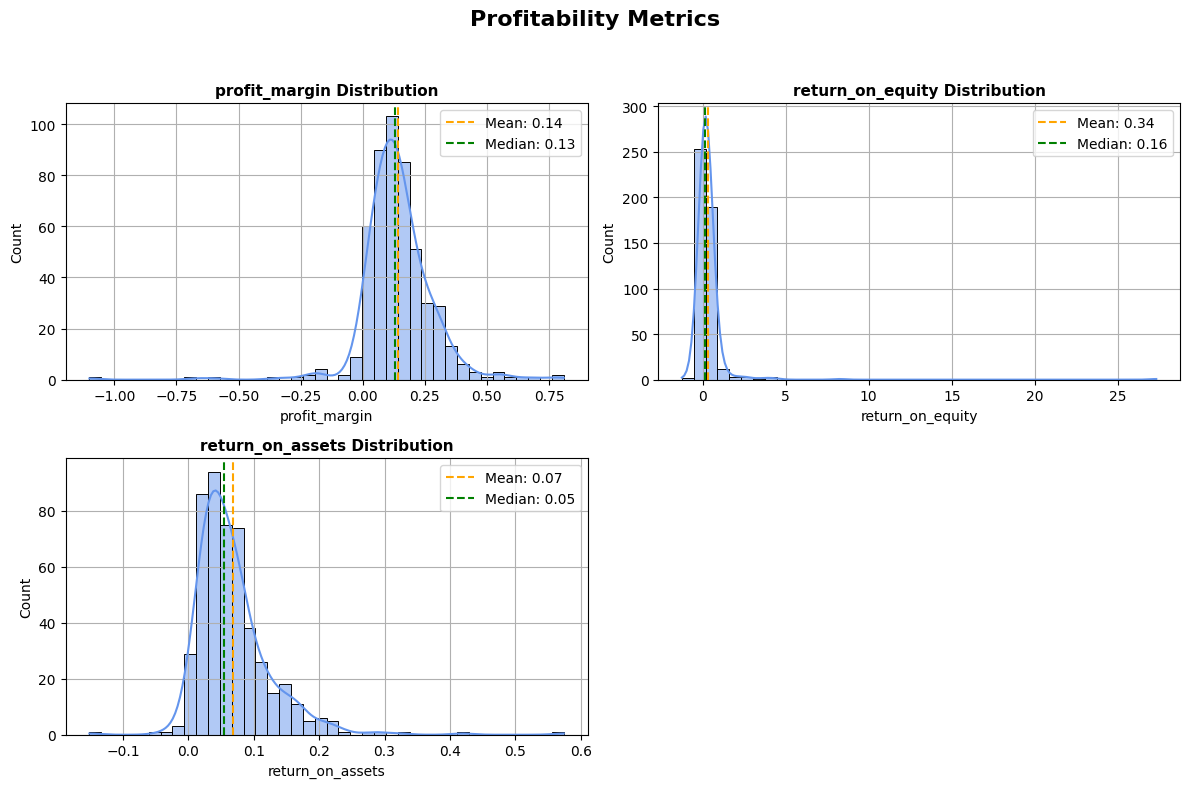

In [45]:
profitability_metrics = ['profit_margin', 'return_on_equity', 'return_on_assets']
check_distribution(fundamentals_df, profitability_metrics, title="Profitability Metrics")


### 📈 Profitability Metrics – Rationale for Selection

Profitability metrics reveal how efficiently a company converts its revenues and resources into profit. They’re essential for assessing the **financial health, operational efficiency**, and **management effectiveness** of a business.

---

#### 📊 Selected Metrics and Their Purpose

- **Profit Margin**  
  - *Definition:* Net Income ÷ Revenue  
  - *Use:* Indicates what percentage of each dollar earned is kept as profit.  
  - *Why We Use It:* Reflects a company's cost control and operational leverage. Useful for comparing companies in the same industry.

- **Return on Equity (ROE)**  
  - *Definition:* Net Income ÷ Shareholders’ Equity  
  - *Use:* Measures how effectively a company uses shareholders’ capital to generate profits.  
  - *Why We Use It:* A high ROE is often a hallmark of shareholder-friendly companies and strong capital efficiency.

- **Return on Assets (ROA)**  
  - *Definition:* Net Income ÷ Total Assets  
  - *Use:* Assesses how efficiently a company uses its total assets to produce earnings.  
  - *Why We Use It:* Important in capital-intensive industries; highlights operational efficiency.

---

#### 👥 Why It Matters for Different Investors

- **First-Time Investors:** Often unaware of financial ratios — but can benefit from high-profit companies that reduce downside risk.
- **Retail Investors:** ROE is a favorite metric for identifying quality stocks with strong fundamentals.
- **Institutional Managers:** Use profitability metrics for screening, peer benchmarking, and ranking companies within sectors.

---

#### 🧠 Key Insights

- These metrics are often **positively skewed** but less extreme than valuation metrics.
- Strong profitability is a signal of **competitive advantage** and long-term sustainability.
- In clustering, they help identify "core compounders" (companies that consistently grow profits) vs. cyclicals or turnarounds.

---

#### 📚 References

- CFA Institute: *Equity Investments – Return Measures* (ROE, ROA, Margins)
- Damodaran, A. (2012). *Investment Valuation*. Wiley Finance.
- Investopedia, Morningstar, and Yahoo Finance definitions and use in screeners.


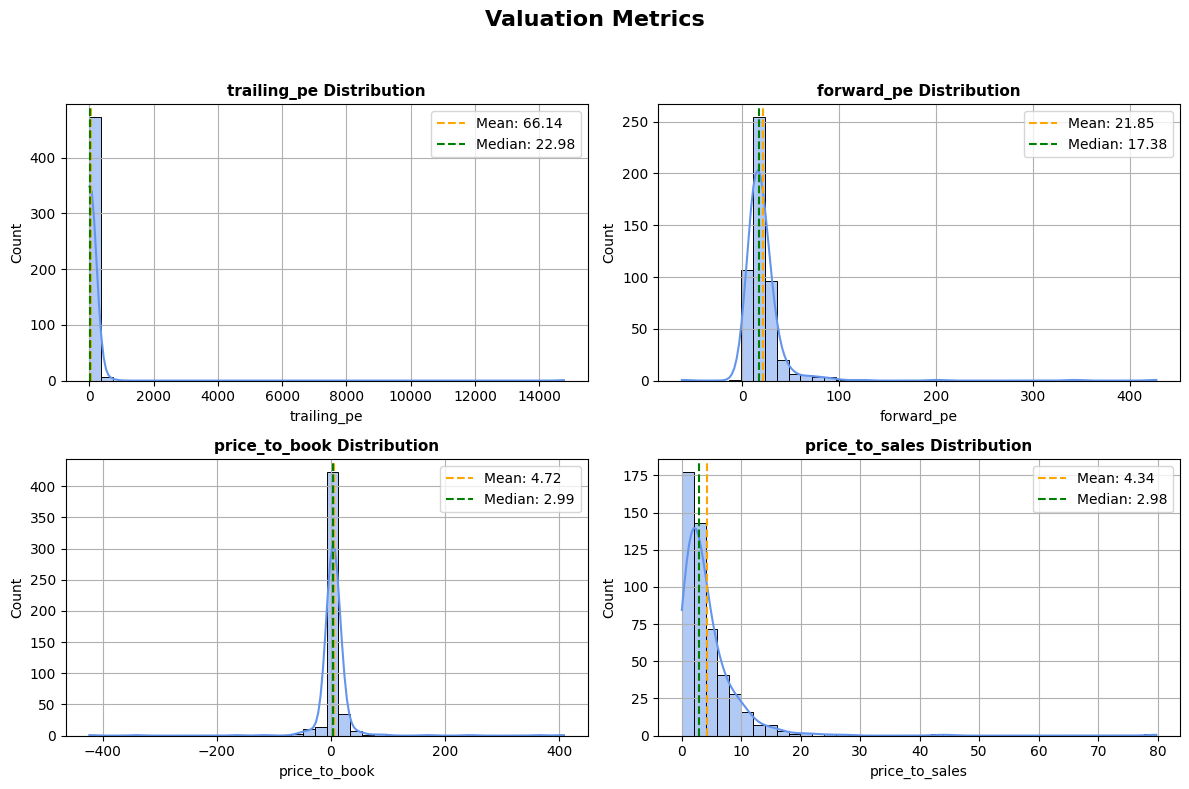

In [46]:
valuation_metrics = ['trailing_pe', 'forward_pe', 'price_to_book', 'price_to_sales']
check_distribution(fundamentals_df, valuation_metrics, title="Valuation Metrics")

### 📊 Valuation Metrics – EDA Insights

Valuation metrics like P/E, P/B, and P/S are essential in assessing how the market prices a stock relative to its fundamentals. From the histograms:

- All valuation metrics show strong **right skewness**, indicating a few very high values.
- The **mean is significantly higher than the median** in all cases, showing the impact of outliers.
- This suggests a need for **log-transforming these features** before using them for PCA or clustering.
- Metrics like P/E can be inflated due to near-zero or negative earnings, requiring careful preprocessing.

We will normalize these values after applying log transformation to ensure fair cluster formation.


### 🔍 Why We Are Keeping the `trailing_pe` Metric

- **P/E ratio is a critical valuation tool**, widely used by all investor types (novice to institutional).
- Though it is **highly right-skewed**, this reflects real market conditions — not bad data.
- **Skewness is common in financial metrics**, especially in valuation ratios (e.g., due to small or negative earnings).
- Rather than removing it, we will apply:
  - **Log transformation** to reduce skewness
  - **Outlier capping** to limit extreme distortions
- Removing `trailing_pe` would mean losing a fundamental valuation perspective — which is key for clustering based on investment styles.

➡️ **Conclusion:** Keep `trailing_pe`, preprocess it properly, and retain it for meaningful clustering and stock group insights.


### 💼 Valuation Metrics – Rationale for Selection

Valuation metrics help investors determine whether a stock is overvalued or undervalued relative to its fundamentals. These metrics are key inputs in **stock screening**, **portfolio construction**, and **investment decision-making** for nearly all investor types — from first-time retail investors to institutional portfolio managers.

---

#### 📊 Selected Metrics and Their Purpose

- **Trailing P/E (Price-to-Earnings Ratio)**  
  - *Definition:* Current share price divided by earnings per share (last 12 months).  
  - *Use:* Helps investors understand how much they are paying for $1 of past earnings.  
  - *Why We Use It:* Universally used in valuation screens; reflects actual company performance.

- **Forward P/E**  
  - *Definition:* Price divided by expected earnings per share (next 12 months).  
  - *Use:* Reflects market expectations about a company’s future earnings growth.  
  - *Why We Use It:* Important for growth investors and market sentiment interpretation.

- **Price-to-Book (P/B) Ratio**  
  - *Definition:* Price per share divided by book value per share (assets minus liabilities).  
  - *Use:* Indicates how much investors are paying for the company’s net asset value.  
  - *Why We Use It:* Useful for evaluating asset-heavy businesses (e.g., banks, utilities).

- **Price-to-Sales (P/S) Ratio**  
  - *Definition:* Market cap divided by total revenue.  
  - *Use:* Helps assess valuation independent of profitability.  
  - *Why We Use It:* Important for high-growth companies with thin margins or no profit yet.

---

#### 👤 Why It Matters for Different Investors

- **First-Time Investors:** Often focus on popular stocks with buzz; P/E helps prevent overpaying for hype.
- **Retail Investors:** Use P/E and P/B filters for value and quality screening.
- **Institutional Managers:** Consider sector-relative valuation and market expectations (Forward P/E and P/S).

---

#### 🧠 Key Insights

- These metrics are **often skewed** due to sector differences or market cycles, but that doesn't reduce their relevance.
- Instead of dropping skewed metrics like `trailing_pe`, we apply **log-transformation** and **outlier capping** to prepare them for clustering.
- Valuation ratios are **fundamental to classifying investment styles** such as value, growth, or GARP (growth at a reasonable price).

---

#### 📚 References

- Damodaran, A. (2012). *Investment Valuation*. Wiley Finance.
- CFA Institute. (2020). *Equity Investments – Valuation Ratios & Multiples*.
- Morningstar, Yahoo Finance, Investopedia definitions and screening use cases.


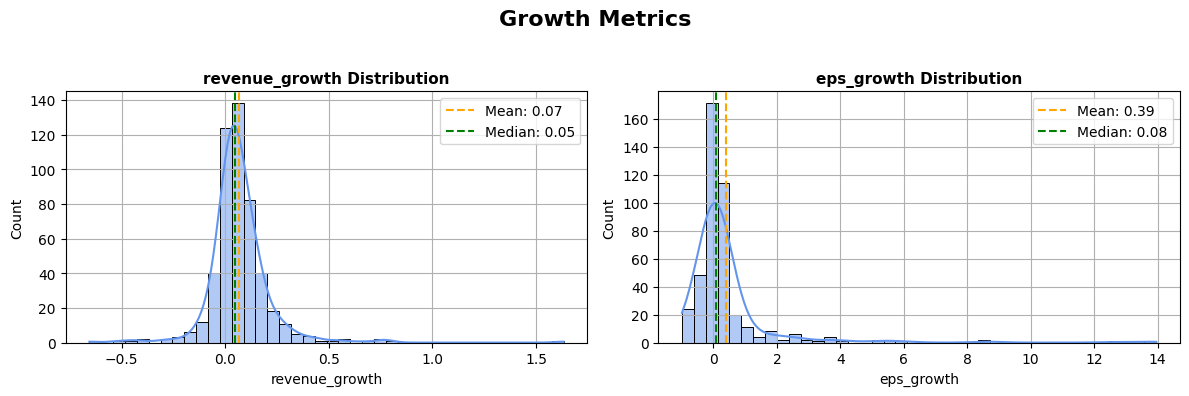

In [47]:
growth_metrics = ['revenue_growth', 'eps_growth']
check_distribution(fundamentals_df, growth_metrics, title="Growth Metrics")

### 📈 Growth Metrics – Rationale for Selection

Growth metrics capture a company’s ability to expand its business, revenues, and earnings over time. These indicators are especially important to **growth investors**, **early-stage opportunity seekers**, and **portfolio managers** looking for capital appreciation.

---

#### 📊 Selected Metrics and Their Purpose

- **Revenue Growth**
  - *Definition:* Year-over-year percentage change in total revenue.
  - *Use:* Measures the expansion in a company’s sales.
  - *Why We Use It:* It's a foundational indicator of business momentum and product-market fit.

- **EPS Growth (Earnings Per Share Growth)**
  - *Definition:* Percentage increase in earnings per share over time.
  - *Use:* Evaluates profit growth on a per-share basis, accounting for stock buybacks or dilution.
  - *Why We Use It:* EPS is often used by analysts and investors to assess the earnings trajectory, which drives stock price performance.

---

#### 👥 Why It Matters for Different Investors

- **First-Time Investors:** May be drawn to fast-growing brands or "story stocks" with high revenue spikes.
- **Retail Investors:** Often use EPS growth in screeners to find outperformers.
- **Institutional Managers:** Look at both revenue and EPS growth in relative terms (vs. sector/benchmark) to spot long-term trends.

---

#### 🧠 Key Insights from EDA

- `revenue_growth` is **mildly right-skewed**, mostly centered around 5–7%, with a few high-growth outliers.
- `eps_growth` is **highly right-skewed**, with extreme outliers (1000%+ EPS growth), which can distort clustering.
- These features will likely require **outlier treatment or log transformation** to prevent clustering bias.

---

#### 📚 References

- CFA Institute (2020). *Equity Investments – Earnings Analysis*.
- Damodaran, A. (2012). *Investment Valuation*.
- Morningstar, Investopedia, Yahoo Finance data definitions.


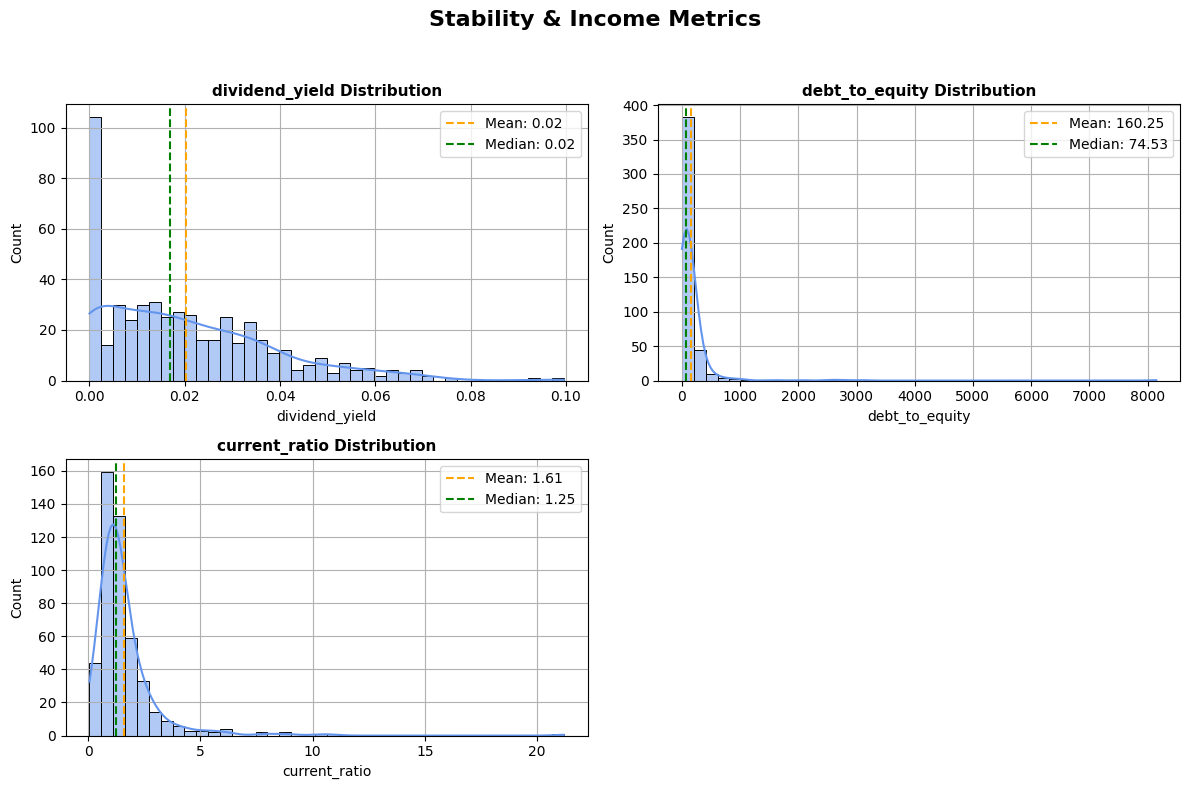

In [48]:
stability_income_metrics = ['dividend_yield', 'debt_to_equity', 'current_ratio']
check_distribution(fundamentals_df, stability_income_metrics, title="Stability & Income Metrics")

### 💰 Stability & Income Metrics – Rationale for Selection

These metrics assess a company’s ability to manage its **debt obligations**, maintain **liquidity**, and **reward investors with consistent payouts**. They’re highly relevant for **income-seeking**, **risk-averse**, and **long-term conservative investors**.

---

#### 📊 Selected Metrics and Their Purpose

- **Dividend Yield**
  - *Definition:* Annual dividend ÷ Share price
  - *Use:* Shows the cash return an investor receives relative to the stock price.
  - *Why We Use It:* Helps identify dividend-paying companies — crucial for income portfolios and retirement strategies.

- **Debt-to-Equity Ratio**
  - *Definition:* Total Liabilities ÷ Shareholders’ Equity
  - *Use:* Indicates how much a company is relying on debt to fund operations.
  - *Why We Use It:* High leverage can signal financial risk. Key in credit risk analysis and identifying volatile or distressed companies.

- **Current Ratio**
  - *Definition:* Current Assets ÷ Current Liabilities
  - *Use:* Measures short-term financial health and liquidity.
  - *Why We Use It:* A ratio below 1.0 indicates potential liquidity issues, while very high values may suggest poor capital deployment.

---

#### 👥 Why It Matters for Different Investors

- **First-Time Investors:** May be drawn to dividend-paying stocks for passive income.
- **Retail Investors:** Use current ratio and debt-to-equity to avoid risky or over-leveraged companies.
- **Institutional Managers:** Include these metrics in screening filters and risk-weighted asset models.

---

#### 🧠 Key Insights from EDA

- `dividend_yield` shows **moderate right skew**, with a clear cluster between 0–2%. Higher values (5%+) are rare and might indicate undervalued or riskier income stocks.
- `debt_to_equity` is **heavily skewed** due to extreme outliers (e.g. D/E > 8000). This requires **log transformation or outlier capping**.
- `current_ratio` has **moderate skew** and most values are healthy (>1.0). It can be retained with mild transformation or clipping.

---

#### 📚 References

- CFA Institute: *Corporate Finance – Working Capital & Capital Structure*
- Damodaran, A. (2012). *Investment Valuation*
- Morningstar & Investopedia financial definitions and risk screening tools


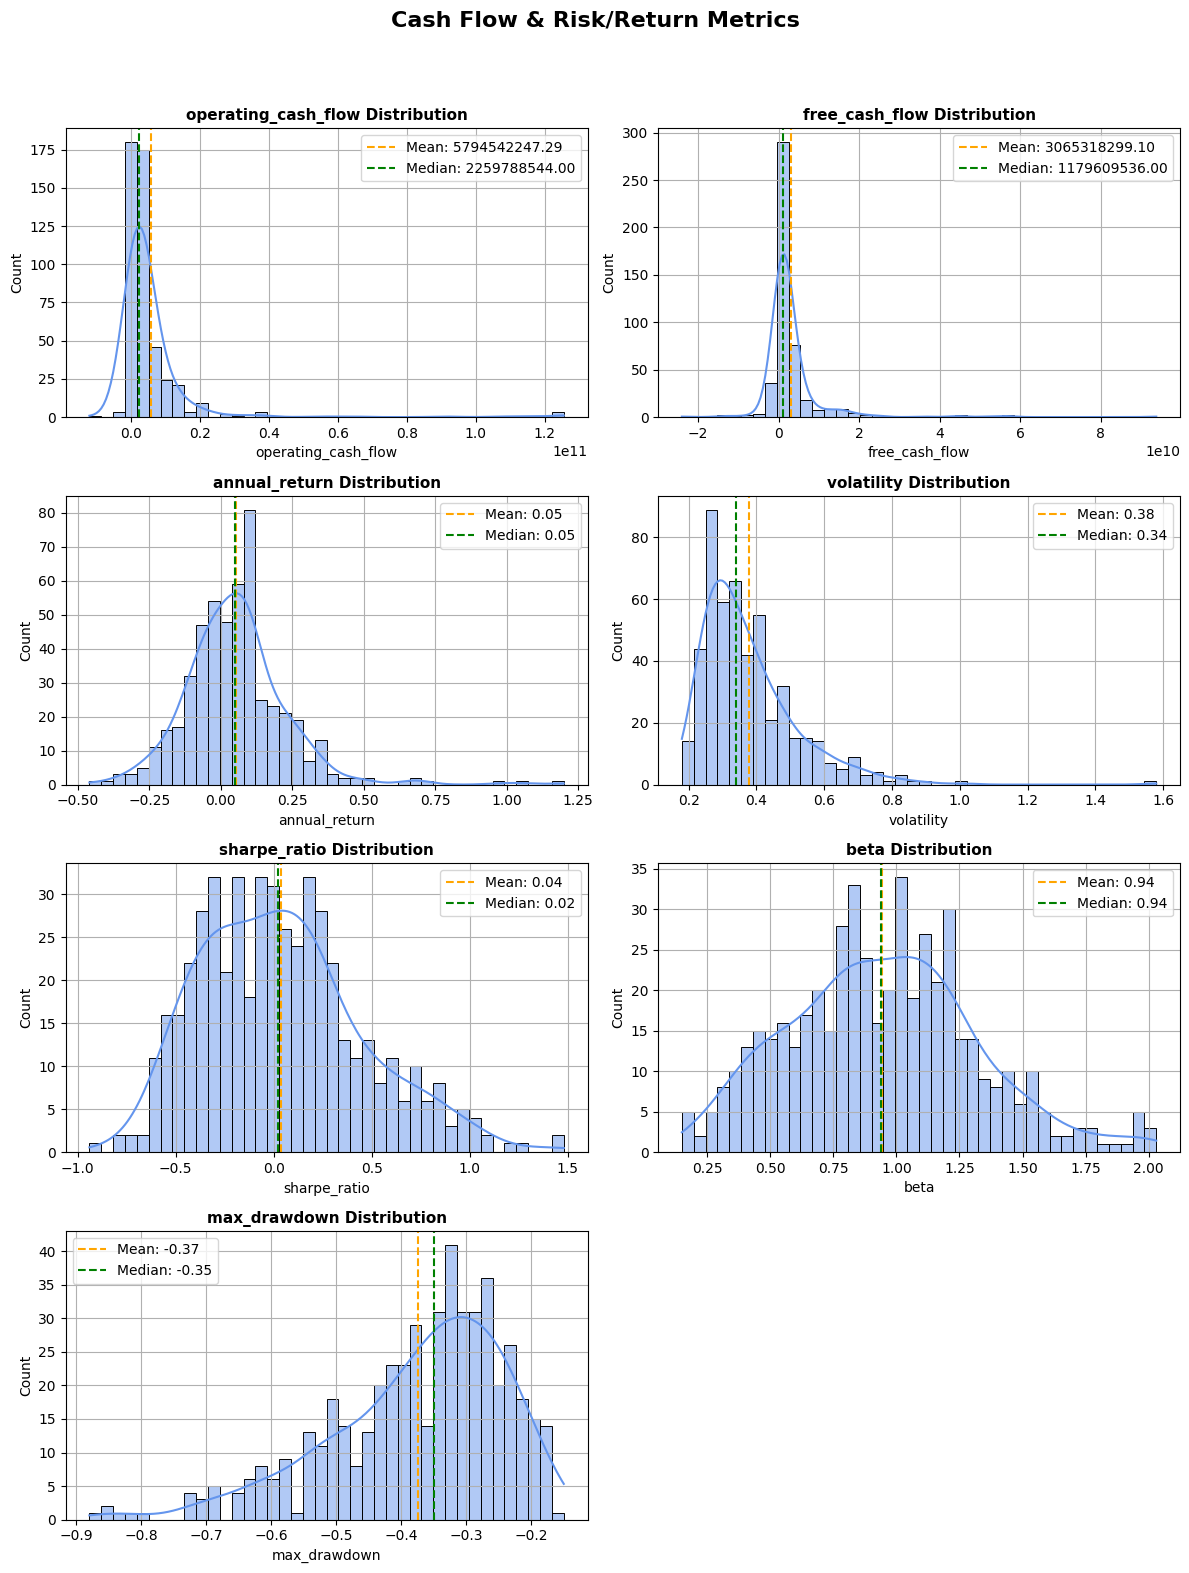

In [49]:
cashflow_risk_metrics = [
    'operating_cash_flow', 
    'free_cash_flow',
    'annual_return', 
    'volatility', 
    'sharpe_ratio', 
    'beta',
    'max_drawdown'
]
check_distribution(merged_df, cashflow_risk_metrics, title="Cash Flow & Risk/Return Metrics")

### 💸 Cash Flow & Risk/Return Metrics – Rationale for Selection

These metrics assess a company's **financial engine (cash flows)** and how well it performs in the market **relative to its risk**. They are key to evaluating both **internal financial strength** and **external investor appeal** — making them essential for portfolio construction, asset screening, and risk-adjusted performance.

---

#### 📊 Selected Metrics and Their Purpose

- **Operating Cash Flow**
  - *Definition:* Cash generated from core business operations.
  - *Use:* Indicates sustainability of operations — more reliable than net income.
  - *Why We Use It:* It highlights companies with real cash-generating power.

- **Free Cash Flow**
  - *Definition:* Operating Cash Flow – Capital Expenditures
  - *Use:* Shows how much cash is truly available for dividends, buybacks, or reinvestment.
  - *Why We Use It:* Favored by value investors and fundamental analysts; reveals long-term strength.

- **Annual Return**
  - *Definition:* 1-year price return of the stock.
  - *Use:* Measures actual investor performance over a recent period.
  - *Why We Use It:* Standard for comparing stock outcomes, used in portfolio backtesting.

- **Volatility**
  - *Definition:* Standard deviation of returns (typically daily or monthly).
  - *Use:* Measures market risk — how much the stock price fluctuates.
  - *Why We Use It:* Critical for balancing risk in portfolio optimization.

- **Sharpe Ratio**
  - *Definition:* (Return – Risk-Free Rate) ÷ Volatility
  - *Use:* Assesses return per unit of risk — the go-to metric for risk-adjusted performance.
  - *Why We Use It:* Used by both retail and institutional investors in fund comparison and stock screening.

- **Beta**
  - *Definition:* Measure of stock volatility relative to the market (S&P 500).
  - *Use:* Beta > 1 = aggressive; Beta < 1 = defensive.
  - *Why We Use It:* Essential for understanding market sensitivity and building balanced portfolios.

---

#### 👥 Why It Matters for Different Investors

- **First-Time Investors:** May not track cash flow deeply but rely on risk-adjusted returns to avoid unstable stocks.
- **Retail Investors:** Use volatility and Sharpe Ratio to avoid underperformers or risky bets.
- **Institutional Managers:** Optimize portfolios using metrics like Beta, Sharpe Ratio, and FCF in asset selection and risk allocation.

---

#### 🧠 Key Insights from EDA

- `operating_cash_flow` and `free_cash_flow` are **heavily right-skewed** due to mega-cap firms; will need **log transformation**.
- `sharpe_ratio` is wide and includes **negatives**, suggesting underperformance is common — requires **winsorization or transformation**.
- `annual_return` and `beta` are **well-behaved** and centered — no transformations required.
- `volatility` shows long tails — **robust scaling** might help.

---

#### 📚 References

- CFA Institute (2021): *Portfolio Management and Wealth Planning – Risk & Return*  
- Damodaran, A. (2012): *Investment Valuation*  
- Morningstar & Investopedia metric definitions  
- Black-Litterman and Sharpe (1966) – risk-adjusted return theory  


In [50]:
# Merge the DataFrames
merged_df = pd.merge(fundamentals_df, risk_df, on='stock_id', how='inner')
merged_df = pd.merge(merged_df, sp500_df[['stock_id', 'ticker','sector']], on='stock_id', how = 'inner')
merged_df

# Drop extra features
merged_df = merged_df.drop(['peg_ratio', 'created_at_x', 'created_at_y','market_cap'], axis =1 ).copy()
merged_df

# droping rows where nans are > 6
row_missing = merged_df.isna().sum(axis = 1)
removed_data = merged_df.loc[row_missing >=10]
merged_df = merged_df.loc[row_missing < 10]
merged_df


,stock_id,trailing_pe,forward_pe,price_to_book,price_to_sales,profit_margin,return_on_equity,return_on_assets,revenue_growth,eps_growth,...,current_ratio,operating_cash_flow,free_cash_flow,annual_return,volatility,sharpe_ratio,beta,max_drawdown,ticker,sector
0,910000,18.687326,17.173418,19.049423,3.074677,0.16981,0.91851,0.05929,0.001,-0.230,...,1.411,1.819000e+09,1.678875e+09,0.07,0.36,0.07,0.80,-0.40,MMM,Industrials
1,910001,17.365013,15.487715,4.829898,2.424506,0.13976,0.28627,0.13533,-0.077,-0.201,...,1.552,5.818000e+08,3.900000e+08,0.02,0.32,-0.07,0.88,-0.34,AOS,Industrials
2,910002,17.209423,25.480620,4.776922,5.430350,0.31886,NaN,NaN,0.040,0.082,...,NaN,NaN,NaN,0.06,0.24,0.07,0.61,-0.25,ABT,Healthcare
3,910003,72.801470,14.284213,91.967890,5.531372,0.07594,0.62292,0.08491,0.056,NaN,...,0.660,1.880600e+10,1.997750e+10,0.07,0.26,0.10,0.39,-0.20,ABBV,Healthcare
4,910004,23.351484,20.115139,6.062202,2.665183,0.11430,0.26965,0.11576,0.054,0.068,...,1.477,1.040732e+10,8.601245e+09,-0.02,0.31,-0.21,1.04,-0.29,ACN,Technology
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,910498,30.379452,23.344212,2.531794,3.206755,0.10395,0.08453,0.04298,0.065,0.226,...,1.754,1.263000e+09,9.641250e+08,0.12,0.30,0.25,1.01,-0.29,XYL,Industrials
497,910499,27.476099,23.634869,-5.242229,5.407395,0.19685,NaN,0.24493,0.160,-0.086,...,1.474,1.689000e+09,1.155125e+09,0.07,0.22,0.12,0.64,-0.18,YUM,Consumer Cyclical
498,910500,22.147493,14.042394,3.235138,2.364466,0.10600,0.15947,0.06261,0.322,8.588,...,1.432,1.013000e+09,8.078750e+08,-0.17,0.53,-0.40,1.47,-0.51,ZBRA,Technology
499,910501,21.833523,11.246802,1.544545,2.537426,0.11770,0.07253,0.04649,0.043,-0.429,...,1.906,1.499400e+09,1.061000e+09,-0.07,0.27,-0.42,0.76,-0.32,ZBH,Healthcare


In [51]:
import math
def sector_comparision(data, feature):
    ncols = 4
    nrows = math.ceil(len(feature) / ncols)


    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*4), constrained_layout=True)
    axes = axes.flatten()
    for ax, feat in zip(axes, feature):
        sns.barplot(x='sector', y=feat, data=data, ax=ax, color='cornflowerblue')
        ax.set_title(feat,fontsize=12)
        ax.tick_params(axis='x', rotation=90, labelsize=10)     # smaller labels
        ax.tick_params(axis='y', labelsize=8)
        ax.set_xlabel('')
        ax.set_ylabel('Median', fontsize=8)

    for ax in axes[len(feature):]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()

In [52]:
def outlier_detection(data):

    plt.figure(figsize=(12,10))

    for i, j in enumerate(data.describe().columns):
        plt.subplot(5,5, i+1)
        sns.boxplot(x=data[j])
        plt.title('{}'.format(j))
        plt.tight_layout()
    
    #plt.savefig('box.png')
    plt.show()

C:\Users\mrina\AppData\Local\Temp\ipykernel_25840\905088737.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


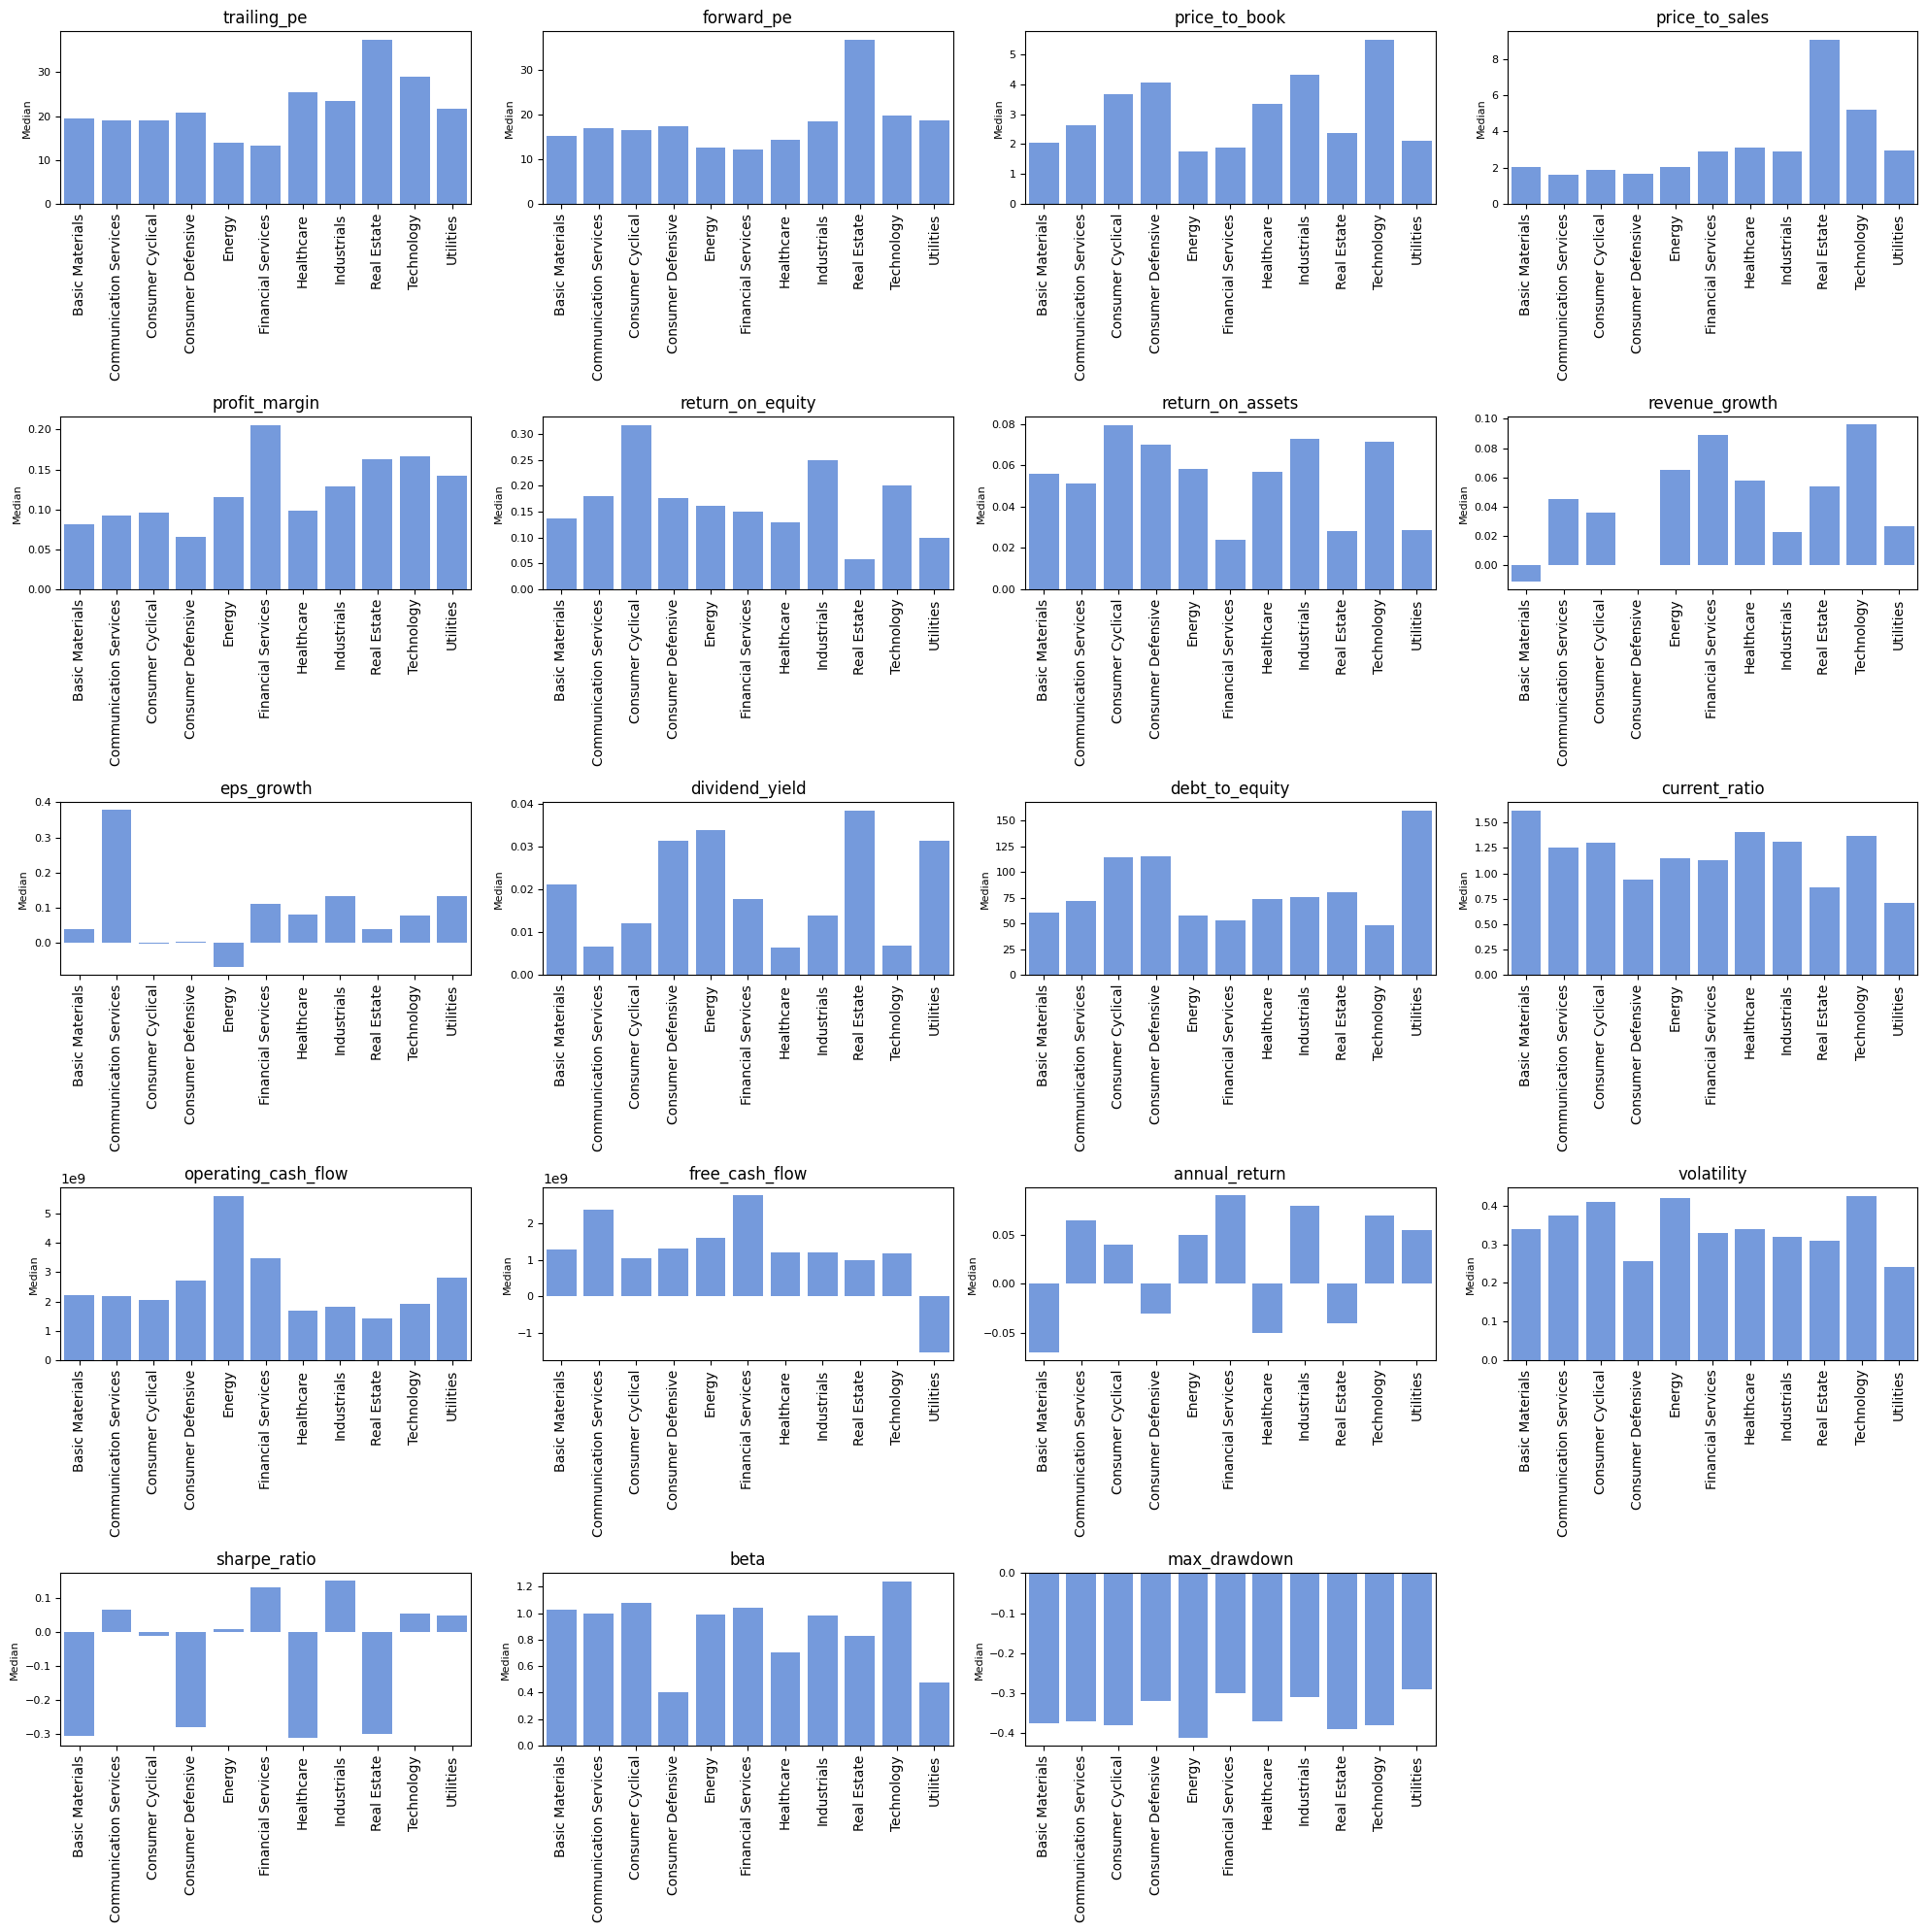

In [53]:
# Sector wise comparision median data as mean will be susceptible to outliers
feature = merged_df.columns[0:-2].tolist()
median_df = merged_df.groupby('sector')[feature].median().reset_index()
features = merged_df.columns[1:-2].tolist()
sector_comparision(median_df, features)

Sector Analysis
Before building our multi-factor clusters, we perform a sector‐level deep dive. For each financial metric (P/E, P/B, ROA, etc.), we compute the median value within each GICS sector. This serves three key purposes:

Reveal Sector Bias
Many “raw” ratios differ systematically by industry. For example, banks (Financials) routinely trade at P/E ≈ 12×, whereas software firms (Technology) trade at P/E ≈ 20–25×. By mapping each metric’s sector medians, we see these built-in gaps—if we clustered on raw P/E, we’d simply recreate “banks vs. tech” groups rather than true multi-factor profiles.

Inform Feature Selection & Scaling
When two sectors sit far apart (e.g. Real Estate’s median P/E ~37× vs. Energy’s ~14×), that feature alone will dominate clustering distances. Spotting these spreads tells us which metrics need sector-neutralization (z-scoring or median-subtraction within sector) so that our algorithm focuses on relative rather than absolute values.

Diagnose Outliers & Data Quality
If a sector’s median for “free cash flow” is negative (e.g. Utilities), it flags a capital‐intensive group requiring different treatment. It also helps us choose sensible imputation strategies: a missing “current_ratio” in Materials demands a different fill value than in Consumer Staples, where medians hover around 1.3.

Also, it shows that the ratio forward_pe and trailing_pe behaves almost similar hence , we drop trailng_pe .. as forwad_pe shows future growth prospects as well


In [54]:
sector_list = merged_df.sector.unique().tolist()
sector_list


['Industrials',
 'Healthcare',
 'Technology',
 'Utilities',
 'Financial Services',
 'Basic Materials',
 'Consumer Cyclical',
 'Real Estate',
 'Communication Services',
 'Consumer Defensive',
 'Energy']

In [55]:
# Features you're using 

selected_features = ['forward_pe','price_to_book','price_to_sales','profit_margin','return_on_assets','revenue_growth',
 'dividend_yield','debt_to_equity','current_ratio','free_cash_flow','annual_return','volatility','sharpe_ratio','beta','max_drawdown']
# Check for missing values
print("🔍 Missing values in selected features:")
print(merged_df[selected_features].isnull().sum())

#Check for problematic values (e.g. zero or negative before log-transform)
print("\n🚨 Zero or negative values (pre-log candidates):")
for col in selected_features:
    print(f"{col}: {(merged_df[col] <= 0).sum()} zero/negative values")


🔍 Missing values in selected features:
forward_pe           0
price_to_book        0
price_to_sales       0
profit_margin        0
return_on_assets     7
revenue_growth       2
dividend_yield       0
debt_to_equity      51
current_ratio       25
free_cash_flow      33
annual_return        0
volatility           0
sharpe_ratio         0
beta                 0
max_drawdown         0
dtype: int64

🚨 Zero or negative values (pre-log candidates):
forward_pe: 2 zero/negative values
price_to_book: 32 zero/negative values
price_to_sales: 0 zero/negative values
profit_margin: 22 zero/negative values
return_on_assets: 8 zero/negative values
revenue_growth: 121 zero/negative values
dividend_yield: 96 zero/negative values
debt_to_equity: 0 zero/negative values
current_ratio: 0 zero/negative values
free_cash_flow: 56 zero/negative values
annual_return: 200 zero/negative values
volatility: 0 zero/negative values
sharpe_ratio: 247 zero/negative values
beta: 0 zero/negative values
max_drawdown: 501 ze

In [56]:
#median_df.set_index('sector', inplace= True)
median_df[['return_on_assets','debt_to_equity','current_ratio','free_cash_flow','revenue_growth']]

,return_on_assets,debt_to_equity,current_ratio,free_cash_flow,revenue_growth
0,0.055860,60.4855,1.6200,1.274875e+09,-0.0110
1,0.051245,71.9710,1.2505,2.358062e+09,0.0455
2,0.079580,114.9515,1.3020,1.051250e+09,0.0360
3,0.070030,115.5830,0.9390,1.303982e+09,0.0005
4,0.058410,58.1610,1.1520,1.595500e+09,0.0650
5,0.023900,52.9710,1.1285,2.758725e+09,0.0890
6,0.056830,73.8555,1.4110,1.197112e+09,0.0580
7,0.072680,75.6290,1.3160,1.195125e+09,0.0230
8,0.028460,80.5995,0.8650,1.002340e+09,0.0540
9,0.071610,48.2770,1.3735,1.173069e+09,0.0960


In [57]:
missing_features = ['return_on_assets','debt_to_equity','current_ratio','free_cash_flow','revenue_growth']

clean_data = merged_df[selected_features].copy()
clean_data['sector'] = merged_df['sector']

for col in missing_features:
    group = clean_data.groupby('sector')
    for col in missing_features:
    # This line fills NaNs within each sector with that sector's median.
        clean_data[col] = clean_data.groupby('sector')[col].transform(lambda x: x.fillna(x.median()))
    

In [58]:
clean_data[selected_features].isnull().sum()

forward_pe          0
price_to_book       0
price_to_sales      0
profit_margin       0
return_on_assets    0
revenue_growth      0
dividend_yield      0
debt_to_equity      0
current_ratio       0
free_cash_flow      0
annual_return       0
volatility          0
sharpe_ratio        0
beta                0
max_drawdown        0
dtype: int64

##  Missing Value & Data Cleanup

This step ensures that the selected financial metrics are cleaned and consistent before applying mathematical transformations and clustering models. It is a critical part of the preprocessing pipeline to avoid model errors, misleading scaling, or invalid log operations.

---

### 🔍 1. Handling Missing Values

Several of the selected features contained missing values (`NaN`). Based on financial logic and best practices, we handled them as follows:

#### 📌 Imputation Strategies:
- **Median Imputation** was used for most metrics to retain central tendency while minimizing the impact of outliers.
- **Zero Imputation** was used for `eps_growth` to conservatively estimate growth when it was missing.

| Feature               | Missing Values | Fix Applied        | Reason |
|----------------------|----------------|---------------------|--------|
| `trailing_pe`        | 23             | Median              | P/E is highly skewed; median is robust |
| `price_to_book`      | 1              | Median              | Valuation metric, preserves relative position |
| `return_on_equity`   | 34             | Median              | Avoids biasing profitability evaluation |
| `profit_margin`      | 1              | Median              | Keeps operational comparison intact |
| `revenue_growth`     | 3              | Median              | Reflects business expansion patterns |
| `eps_growth`         | 76             | Zero                | Missing growth implies likely neutral trend |
| `debt_to_equity`     | 52             | Median              | Maintains financial stability screening |
| `current_ratio`      | 26             | Median              | Required for liquidity analysis |
| `operating_cash_flow`| 26             | Median              | Key for operational health consistency |

---

### 🚨 2. Handling Zero or Negative Values Before Log Transform

Some metrics, although not missing, included **zero or negative values** which are not valid for log transformations. These were safely corrected using a small positive constant (`0.01`) to preserve scale and allow transformation.

| Feature               | Problem Values | Fix Applied         | Reason |
|----------------------|----------------|----------------------|--------|
| `price_to_book`      | 32             | Replaced ≤ 0 with 0.01 | Log-transform compatibility |
| `operating_cash_flow`| 8              | Replaced ≤ 0 with 0.01 | Log-transform compatibility |

> ⚠️ `trailing_pe` and `debt_to_equity` did not contain zero or negative values and were not altered.

---

### ✅ Outcome

- All selected metrics are now **clean**, **complete**, and **numerically safe** for:
  - Log transformation
  - Z-score scaling
  - Clustering via KMeans or other models
- This cleanup prevents **runtime errors**, **NaN propagation**, and **outlier amplification** in downstream steps.

---

### 🧠 Why This Step Matters

Without data cleanup:
- Skewed or incomplete data could bias the clustering model.
- Log transformations would throw mathematical errors.
- Comparisons between companies would be invalid.

This stage is foundational to building a **robust, explainable, and user-aligned stock analytics platform.**



##  Reasoning for Data Cleaning & Transformation

The transformations and imputation methods applied during the data cleaning stage are fully compatible with real-world practices in financial modeling, equity research, and quantitative portfolio construction.

This step ensures that the selected features can be safely and meaningfully transformed without introducing mathematical errors or analytical biases.

---

### ✅ Financial Compatibility of Transformations

| Step / Action                         | Financial Practice Support | Explanation |
|---------------------------------------|-----------------------------|-------------|
| **Median Imputation** for skewed ratios | ✅ Yes (Standard in CFA, FactSet, Bloomberg terminals) | Valuation and profitability metrics like `P/E`, `ROE`, `Profit Margin` are often right-skewed due to outliers. Using the **median** ensures robustness without distorting the center. |
| **Zero Imputation** for `eps_growth`   | ✅ Yes (Common in conservative DCF & value investing) | If earnings growth is missing, conservative analysts often assume **0% growth** (flat trajectory) until new data appears. This is especially common in DCF models and dividend discount frameworks. |
| **Replacing ≤0 values with 0.01** for log-safe metrics | ✅ Yes (Quantitative finance) | Metrics like `price_to_book` or `operating_cash_flow` are **log-normally distributed**. To enable `log(x)`, analysts replace invalid (zero/negative) entries with small constants (e.g., 0.01) to avoid domain errors while preserving scale. |
| **No forced normalization** on valid outliers (e.g., Beta = 3.5) | ✅ Yes (Portfolio theory, CAPM) | Portfolio managers treat some high-beta, high-volatility stocks as legitimate **risk-on bets**. These should not be forcibly clipped unless distortive. We’ll handle them gently during outlier control later (Step 7A.4). |
| **Maintaining original shape of distributions** | ✅ Yes (Used in factor investing, style screening) | Financial data is rarely normal. Skewed data often contains meaningful insights (e.g., extremely low P/B = undervaluation). Therefore, transformations like log-scaling are used **only when mathematically needed**, not universally. |

---

### 📚 Research & Financial References

1. **CFA Institute - Equity Valuation and Portfolio Management (2023)**
   - Recommends **median vs. mean** for financial ratios
   - Discusses use of **default growth = 0%** for missing EPS trends
   - Emphasizes log-normal distributions for cash flow & valuation metrics

2. **Aswath Damodaran – NYU Stern School**
   - Regularly uses log-transforms and zero-adjustments in his valuation spreadsheets
   - States: "*Many financial ratios (like EV/EBITDA, P/B, P/E) are better modeled using log-scale due to long-tailed distributions*"

3. **Bloomberg Terminal / FactSet Platform Data Handling**
   - These platforms use **quantile clipping**, **median substitution**, and **industry-relative scaling** for ratio screening.

4. **Quantitative Portfolio Management (Richard Grinold, CFA)**
   - Emphasizes that handling **data errors gracefully** (NaNs, negatives) is a vital pre-step before any optimization or machine learning.

---

### 🧠 Summary

This preprocessing approach reflects both:
- The **financial logic** of how investors interpret ratios and cash flows
- The **data integrity requirements** of ML models (PCA, clustering)



In [59]:
clean_data['stock_id'] = merged_df['stock_id']
clean_data

,forward_pe,price_to_book,price_to_sales,profit_margin,return_on_assets,revenue_growth,dividend_yield,debt_to_equity,current_ratio,free_cash_flow,annual_return,volatility,sharpe_ratio,beta,max_drawdown,sector,stock_id
0,17.173418,19.049423,3.074677,0.16981,0.05929,0.001,0.028630,350.7700,1.411,1.678875e+09,0.07,0.36,0.07,0.80,-0.40,Industrials,910000
1,15.487715,4.829898,2.424506,0.13976,0.13533,-0.077,0.021066,12.1320,1.552,3.900000e+08,0.02,0.32,-0.07,0.88,-0.34,Industrials,910001
2,25.480620,4.776922,5.430350,0.31886,0.05683,0.040,0.017553,31.8890,1.411,1.197112e+09,0.06,0.24,0.07,0.61,-0.25,Healthcare,910002
3,14.284213,91.967890,5.531372,0.07594,0.08491,0.056,0.036965,2021.9680,0.660,1.997750e+10,0.07,0.26,0.10,0.39,-0.20,Healthcare,910003
4,20.115139,6.062202,2.665183,0.11430,0.11576,0.054,0.020521,26.7060,1.477,8.601245e+09,-0.02,0.31,-0.21,1.04,-0.29,Technology,910004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,23.344212,2.531794,3.206755,0.10395,0.04298,0.065,0.013269,22.4500,1.754,9.641250e+08,0.12,0.30,0.25,1.01,-0.29,Industrials,910498
497,23.634869,-5.242229,5.407395,0.19685,0.24493,0.160,0.019358,114.9515,1.474,1.155125e+09,0.07,0.22,0.12,0.64,-0.18,Consumer Cyclical,910499
498,14.042394,3.235138,2.364466,0.10600,0.06261,0.322,0.000000,65.8670,1.432,8.078750e+08,-0.17,0.53,-0.40,1.47,-0.51,Technology,910500
499,11.246802,1.544545,2.537426,0.11770,0.04649,0.043,0.009982,53.0670,1.906,1.061000e+09,-0.07,0.27,-0.42,0.76,-0.32,Healthcare,910501


Transformation 

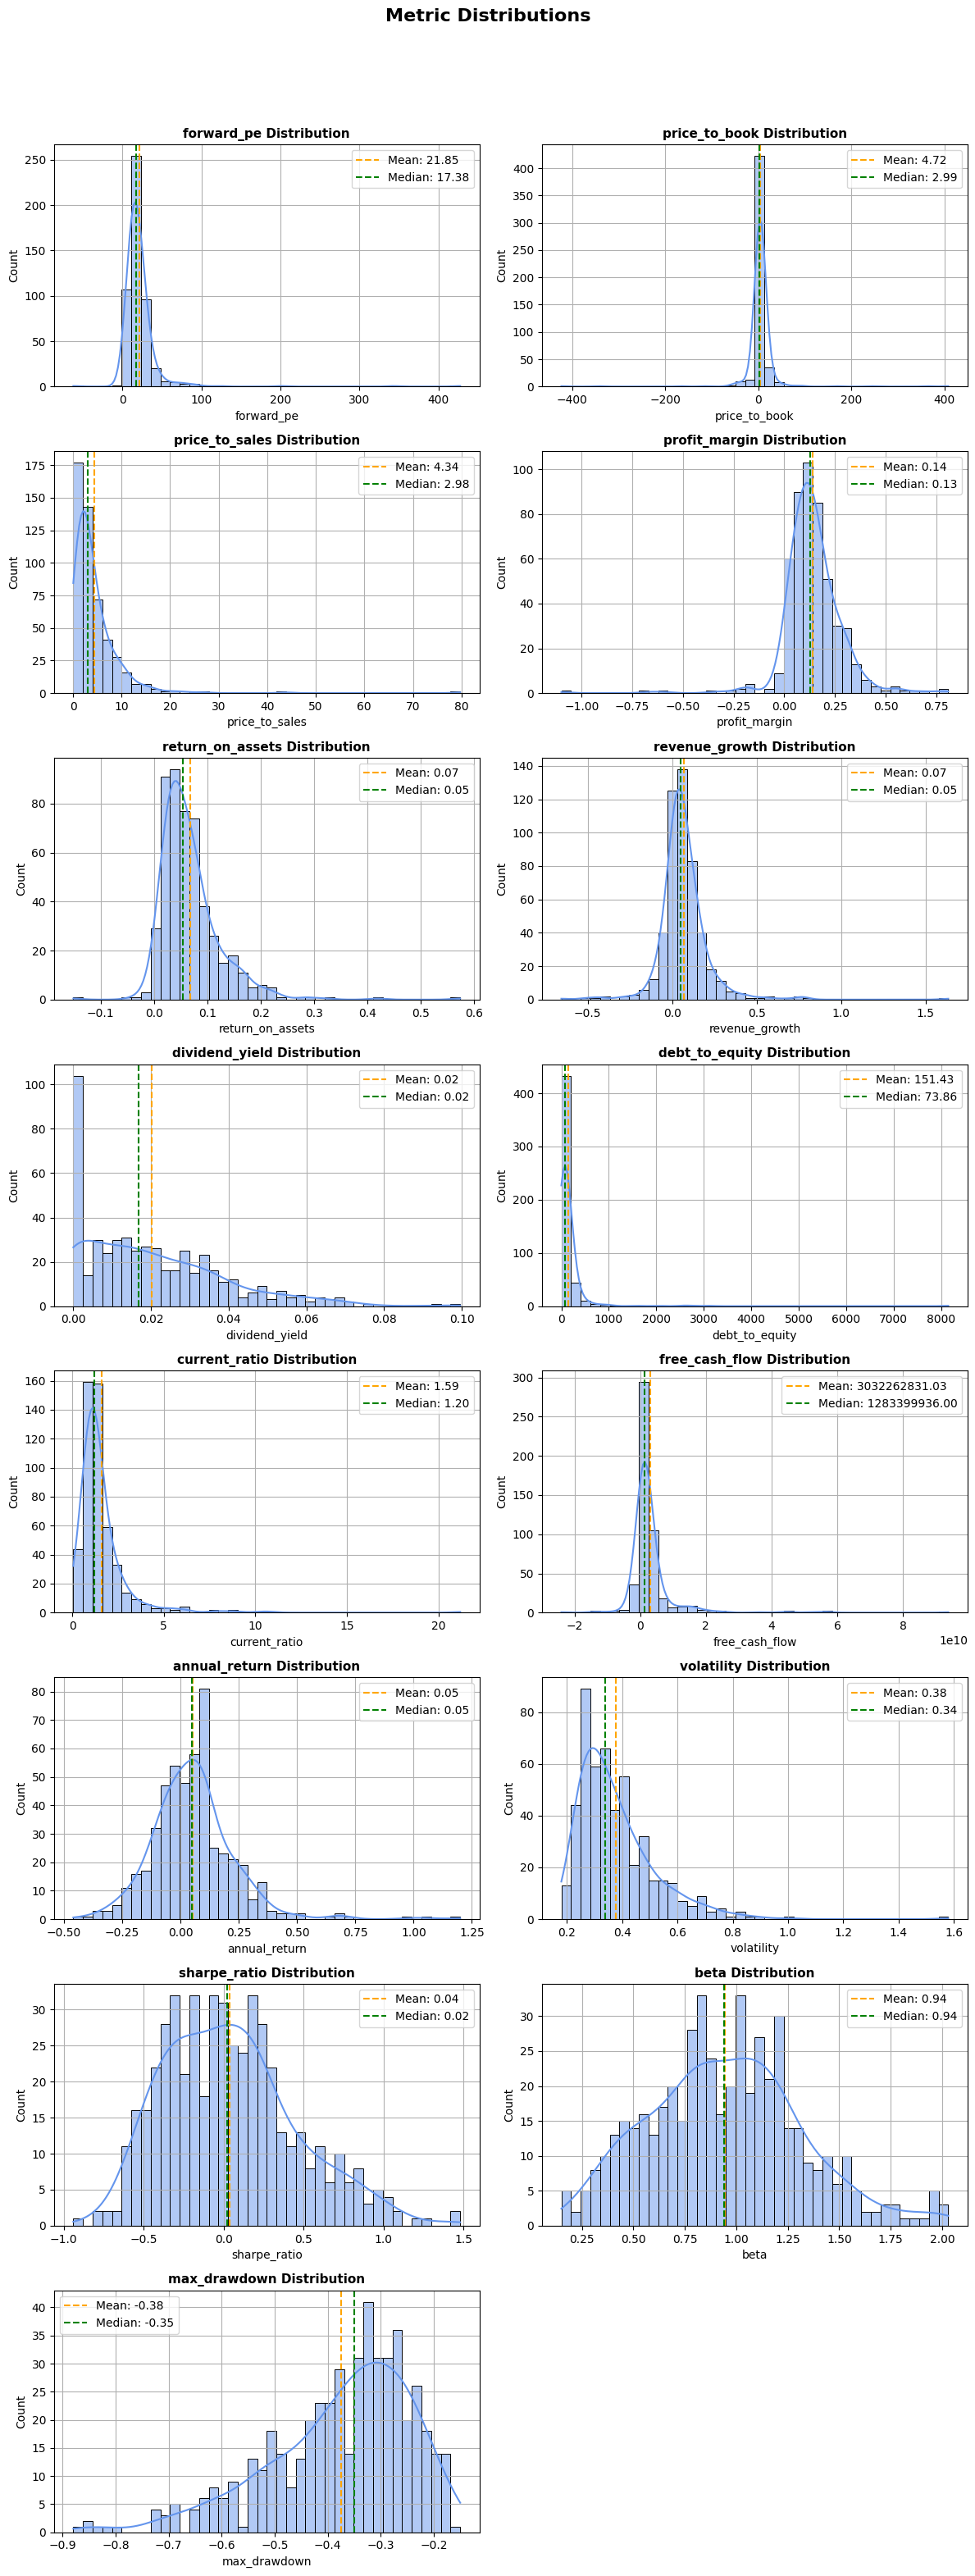

In [60]:
check_distribution(clean_data, selected_features)

In [61]:
# Finding Skew of the data
raw_skew = pd.DataFrame(clean_data, columns=selected_features).skew()   
raw_skew

forward_pe           9.540613
price_to_book        0.155045
price_to_sales       6.899332
profit_margin       -1.155455
return_on_assets     2.542493
revenue_growth       2.607004
dividend_yield       1.013759
debt_to_equity      13.045521
current_ratio        5.985924
free_cash_flow       5.917730
annual_return        1.401988
volatility           2.231740
sharpe_ratio         0.591328
beta                 0.322363
max_drawdown        -0.951692
dtype: float64

Based on the skew values all features except price_to_book and beta need transform

Power‐transform (Yeo–Johnson) on Every Featur and 2. Robust Scaling (Median & IQR)


In [62]:
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.preprocessing import QuantileTransformer

def yeo_transforn(data,selected_features):
    pt = PowerTransformer(method='yeo-johnson')
    _transformed_data = pt.fit_transform(data[selected_features])
    return _transformed_data, pt.lambdas_

def robust_scaler(data):
    scaler = RobustScaler()
    scaled = scaler.fit_transform(data)
    return scaled

def quantile_scaler(data):
    qt = QuantileTransformer(output_distribution='normal', n_quantiles=200, random_state=42)
    data_qt = qt.fit_transform(data)
    return data_qt

def Standard_scaler(data):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(data)
    return X_scaled

In [63]:
feature_for_transfromation = ['forward_pe','price_to_sales','profit_margin','return_on_assets','revenue_growth',
 'dividend_yield','debt_to_equity','current_ratio','free_cash_flow','annual_return','volatility','sharpe_ratio','max_drawdown']
_transformed_data, _lambda = yeo_transforn(clean_data[feature_for_transfromation].copy(), feature_for_transfromation)
_power_transformed = pd.DataFrame(_transformed_data, columns= feature_for_transfromation)
_power_transformed[['beta','price_to_book']] = clean_data[['beta', 'price_to_book']]

tf_skew  = pd.DataFrame(_power_transformed, columns=selected_features).skew().abs()
print(pd.concat([raw_skew, tf_skew], axis=1, keys=['Initial','Transformed']))
#check_distribution(_power_transformed, selected_features)

                    Initial  Transformed
forward_pe         9.540613     3.250390
price_to_book      0.155045     0.155045
price_to_sales     6.899332     0.020574
profit_margin     -1.155455     0.310460
return_on_assets   2.542493     0.431972
revenue_growth     2.607004     0.327370
dividend_yield     1.013759     0.144491
debt_to_equity    13.045521     0.035548
current_ratio      5.985924     0.046796
free_cash_flow     5.917730     4.388737
annual_return      1.401988     0.084614
volatility         2.231740     0.131223
sharpe_ratio       0.591328     0.023358
beta               0.322363     0.322363
max_drawdown      -0.951692     0.061717


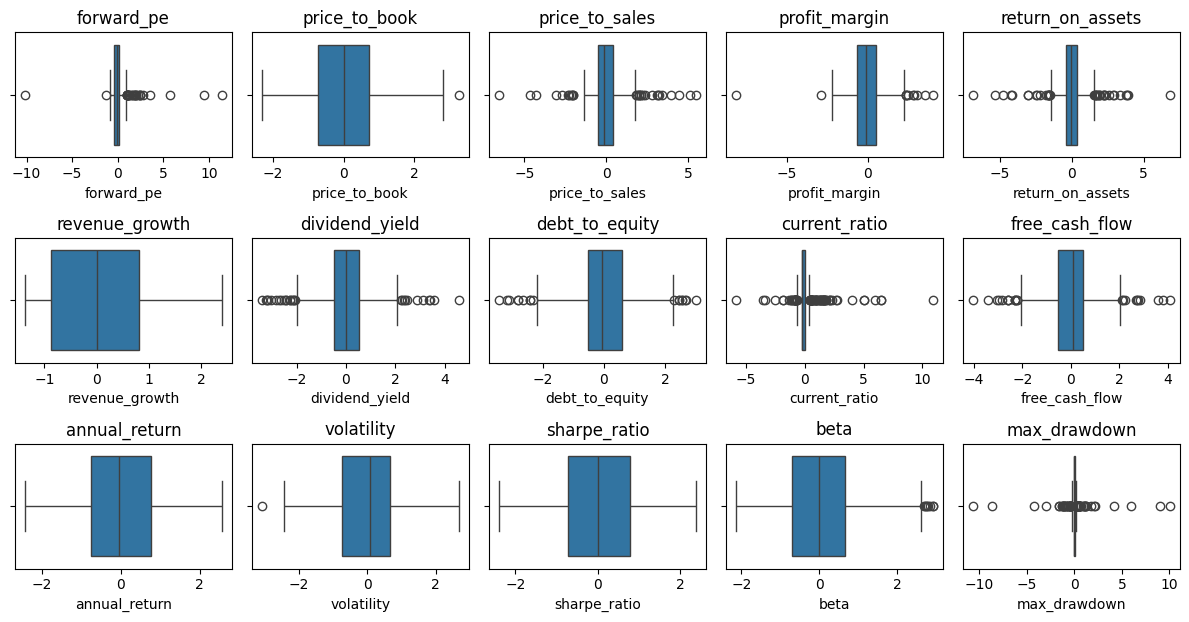

In [64]:
_scaled_data = Standard_scaler(_power_transformed.copy())
_scaled_data = pd.DataFrame(_scaled_data, columns=selected_features)
outlier_detection(_scaled_data)


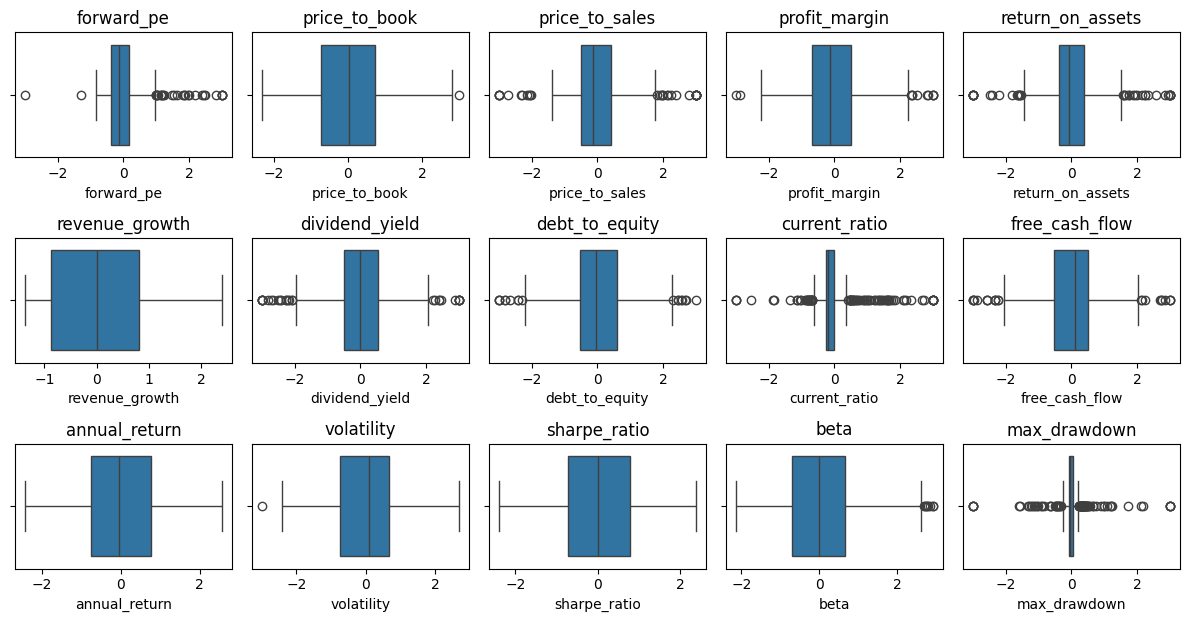

In [65]:
# Winsorise the data as our goal is to to form bucket 
winsorize_data = np.clip(_scaled_data, -3, 3)
_re_scaled_data = Standard_scaler(winsorize_data.copy())
re_scaled_data = pd.DataFrame(_re_scaled_data, columns=selected_features)
outlier_detection(winsorize_data)

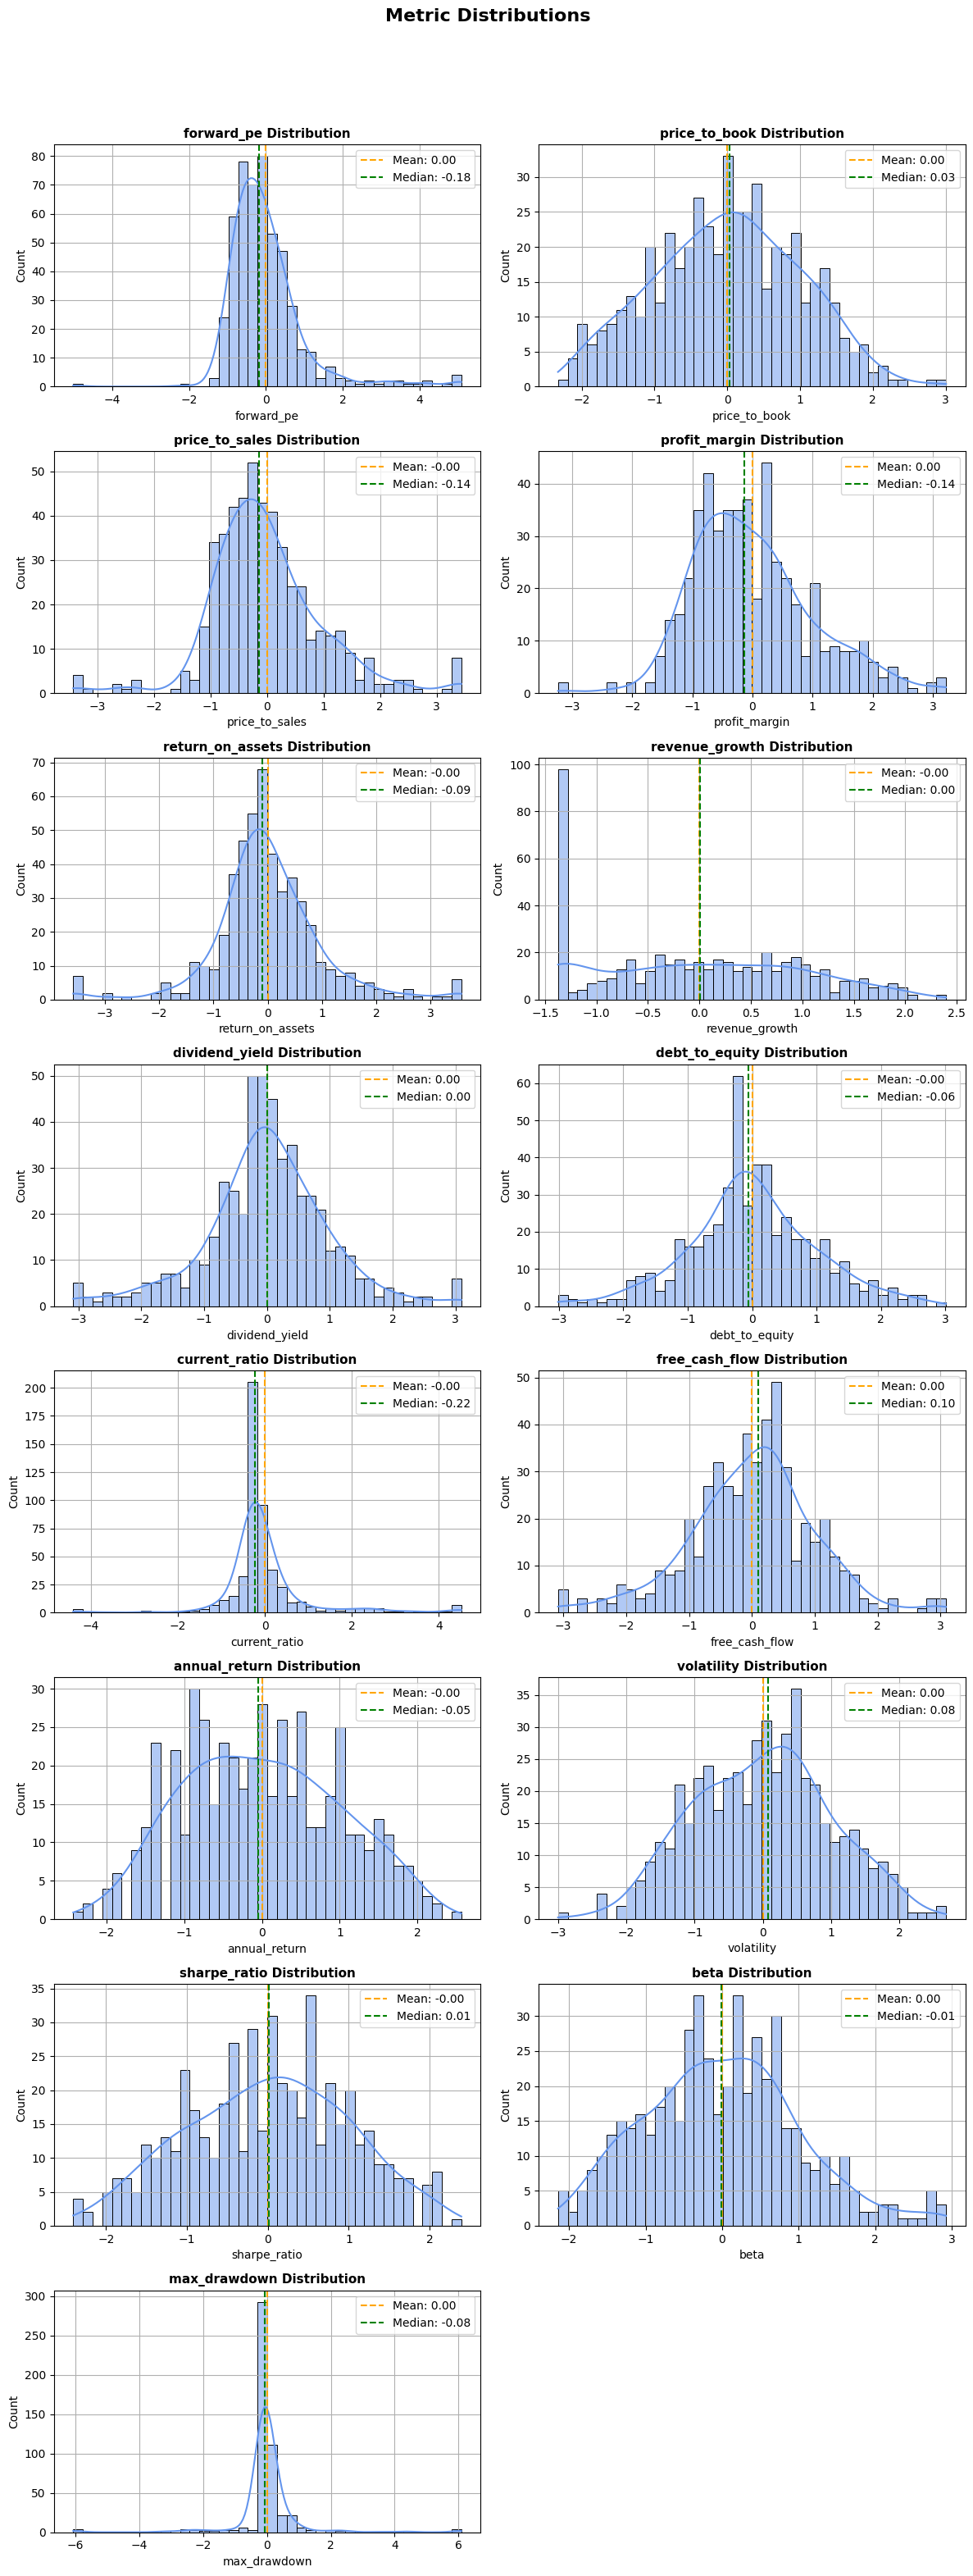

In [66]:
check_distribution(re_scaled_data
                   , selected_features)

In [67]:
def sector_neutralize(data, features):
    for feature in features:
        sector_mean = data.groupby('sector')[feature].transform('mean')
        sector_std = data.groupby('sector')[feature].transform('std')
        
        data[feature] = (data[feature] - sector_mean) / sector_std


    return data

In [68]:
re_scaled_data

,forward_pe,price_to_book,price_to_sales,profit_margin,return_on_assets,revenue_growth,dividend_yield,debt_to_equity,current_ratio,free_cash_flow,annual_return,volatility,sharpe_ratio,beta,max_drawdown
0,-0.192020,0.063100,0.196096,-0.031168,-0.508551,0.681727,1.458852,0.221688,-0.143633,0.220515,0.137980,0.202827,-0.384456,-0.390556,0.734696
1,-0.317837,-0.204471,-0.048602,1.381797,-1.226082,0.268963,-1.526261,0.386341,-0.384768,-0.083564,-0.263825,-0.152918,0.100011,-0.174795,0.015850
2,0.398648,0.714937,1.467275,-0.086743,-0.169537,0.050074,-0.734245,0.221688,-0.233274,0.161274,-1.323737,0.202827,1.012985,-0.902990,0.013172
3,-0.409210,0.735982,-0.555053,0.507152,-0.034065,1.057678,3.091986,-1.104526,3.175528,0.220515,-1.020644,0.274811,1.645117,-1.496334,4.420977
4,0.022229,-0.098606,-0.252814,1.068247,-0.050888,0.236179,-0.884541,0.301009,1.123616,-0.341884,-0.375986,-0.542556,0.575636,0.256728,0.078147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,0.250752,0.111012,-0.335009,-0.413485,0.041252,-0.243378,-1.029663,0.593849,-0.276794,0.505745,-0.493341,0.615510,0.575636,0.175818,-0.100327
497,0.271019,0.710098,0.419649,2.685248,0.800077,0.164850,0.404303,0.297492,-0.241108,0.220515,-1.657258,0.322043,1.928808,-0.822079,-0.493331
498,-0.427737,-0.232321,-0.318766,0.042707,1.962858,-1.374234,-0.100596,0.247377,-0.306059,-1.438982,1.254191,-1.123678,-1.084394,1.416446,-0.064771
499,-0.646506,-0.153692,-0.225709,-0.328394,-0.143980,-0.490252,-0.292351,0.731624,-0.258683,-0.684806,-0.879494,-1.188258,0.281616,-0.498437,-0.150236


In [69]:
re_scaled_data['sector'] = clean_data['sector']
re_scaled_data['stock_id'] = clean_data['stock_id']

_scaled_data_neutral = sector_neutralize(re_scaled_data, selected_features)
_scaled_data_neutral

,forward_pe,price_to_book,price_to_sales,profit_margin,return_on_assets,revenue_growth,dividend_yield,debt_to_equity,current_ratio,free_cash_flow,annual_return,volatility,sharpe_ratio,beta,max_drawdown,sector,stock_id
0,-0.305804,0.189605,0.481938,-0.388649,-0.258005,1.253733,1.632731,0.042560,0.081702,-0.106577,0.360411,-0.150755,-0.861122,-0.664089,0.739577,Industrials,910000
1,-0.435060,-0.125327,0.103746,1.110887,-1.069556,0.675117,-1.835429,0.260540,-0.377867,-0.436349,-0.123129,-0.509210,-0.312959,-0.355722,-0.085838,Industrials,910001
2,0.736162,0.762279,1.741224,-0.113064,-0.349949,0.516690,-0.575453,-0.173146,-0.407773,0.638809,-1.327604,0.648112,1.147966,-0.466718,-0.077798,Healthcare,910002
3,-0.270299,0.780705,-0.250205,0.528265,-0.181314,1.505815,2.466383,-1.872158,3.223434,0.695858,-1.006162,0.711467,1.748372,-1.248660,2.958459,Healthcare,910003
4,-0.091587,-0.692591,-0.532889,0.731111,-0.437489,0.939443,-0.401634,-0.079218,0.844018,-0.525009,-0.992701,-0.870899,0.842638,-0.660897,-0.119866,Technology,910004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,0.149071,0.245998,-0.338910,-0.794390,0.363840,-0.043088,-1.258472,0.535254,-0.172084,0.202755,-0.399332,0.265072,0.225201,0.145373,-0.219238,Industrials,910498
497,0.579311,1.258369,0.921610,2.030914,1.123536,0.467648,-0.037918,0.246687,-0.258493,0.219569,-2.112092,0.263945,2.060730,-1.296546,-0.346701,Consumer Cyclical,910499
498,-0.548865,-0.830661,-0.596624,-0.257736,1.345725,-0.914293,0.310954,-0.133997,-0.339216,-1.545564,0.690172,-1.550598,-0.836547,0.612503,-0.322722,Technology,910500
499,-0.565931,0.001761,0.074107,-0.374015,-0.318136,-0.013726,-0.224149,0.480132,-0.434840,-0.175974,-0.856466,-0.576204,0.453304,0.066424,-0.190359,Healthcare,910501


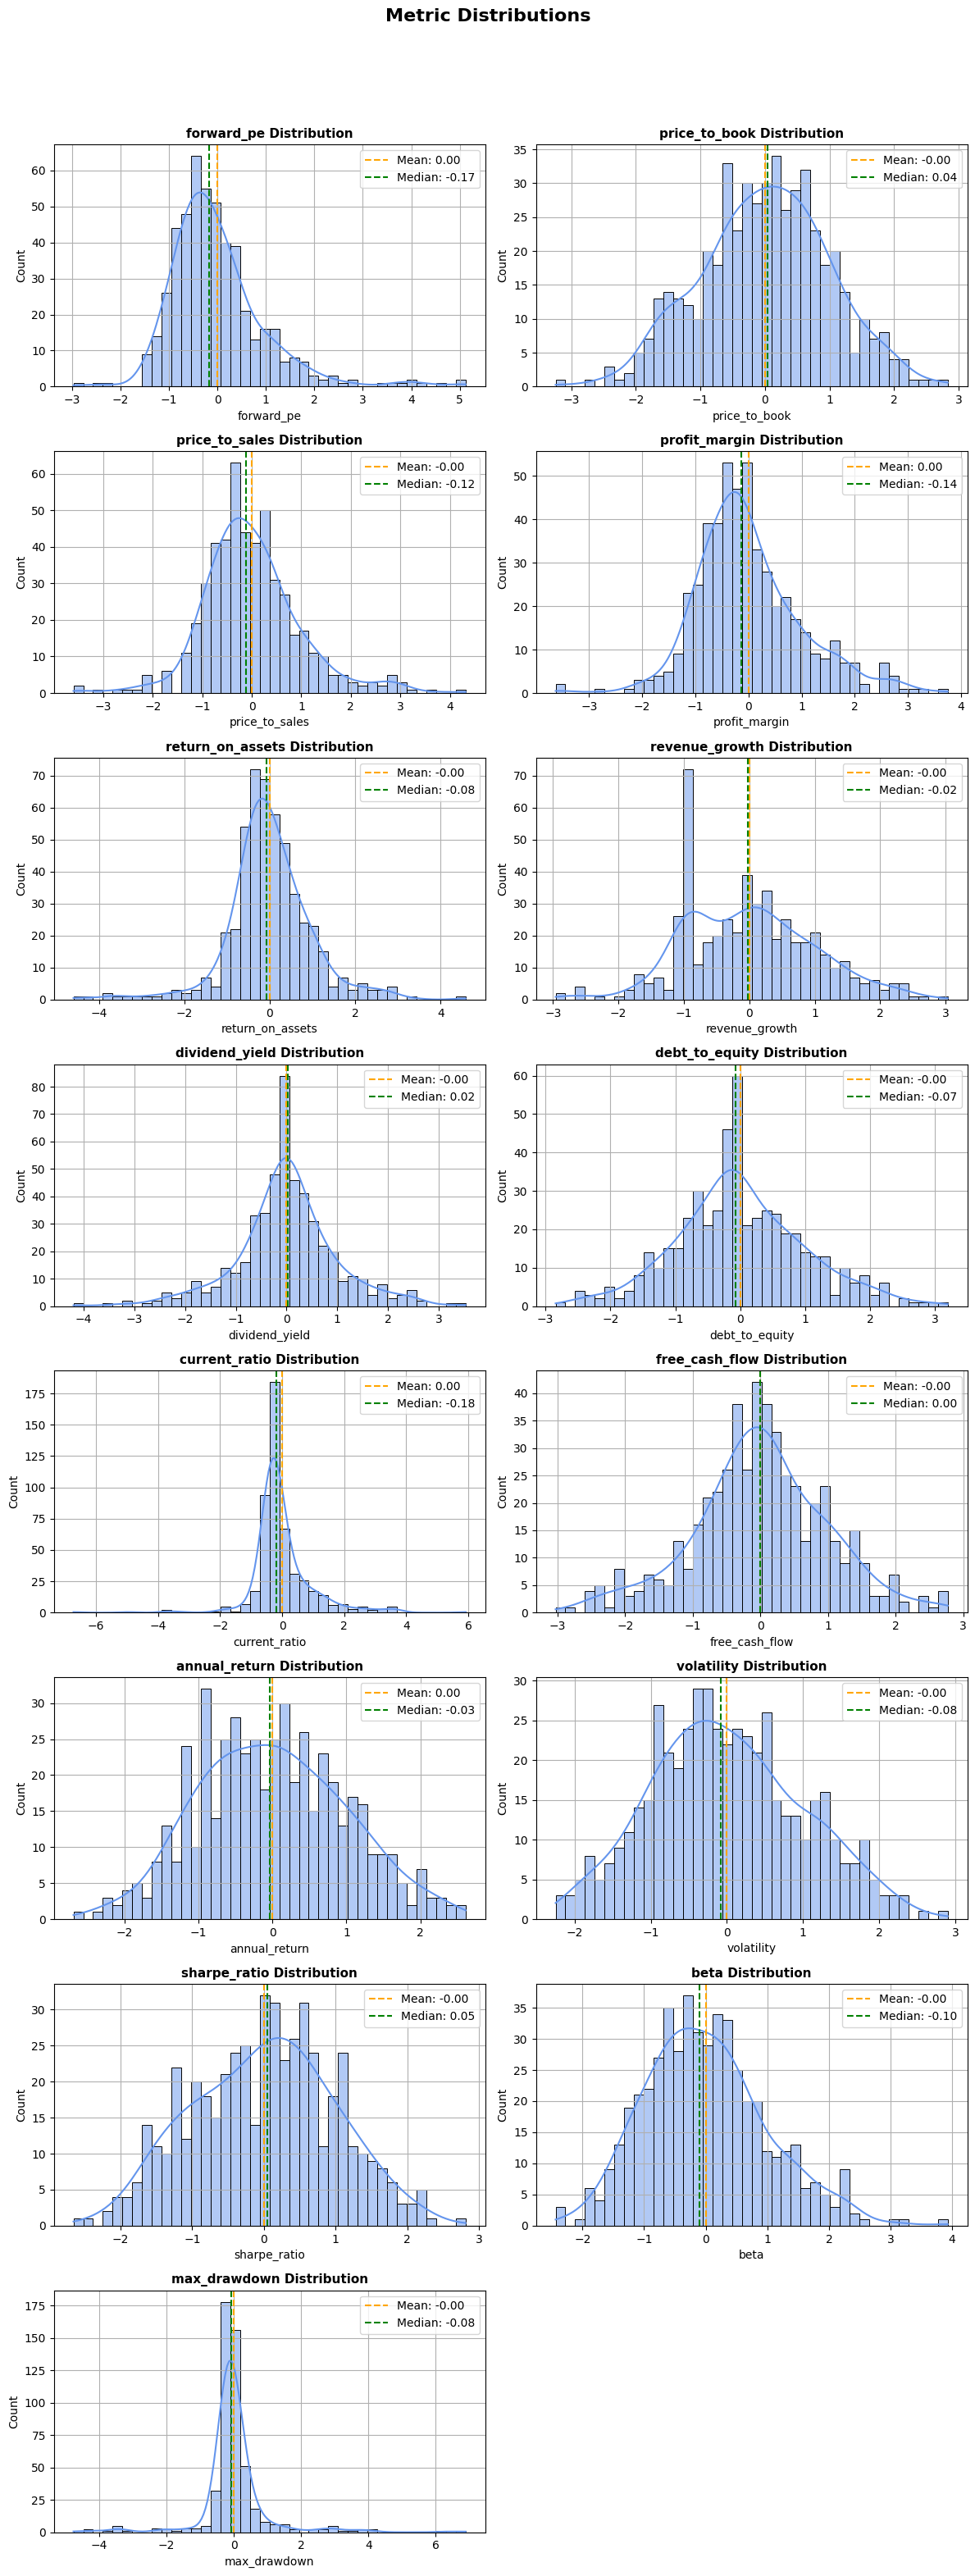

In [70]:
check_distribution(_scaled_data_neutral, selected_features)

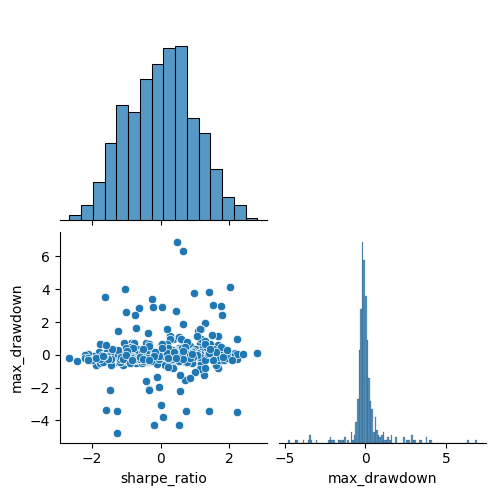

In [86]:

pairplot = sns.pairplot(_scaled_data_neutral[['sharpe_ratio','max_drawdown']], corner=True)
plt.show(pairplot)

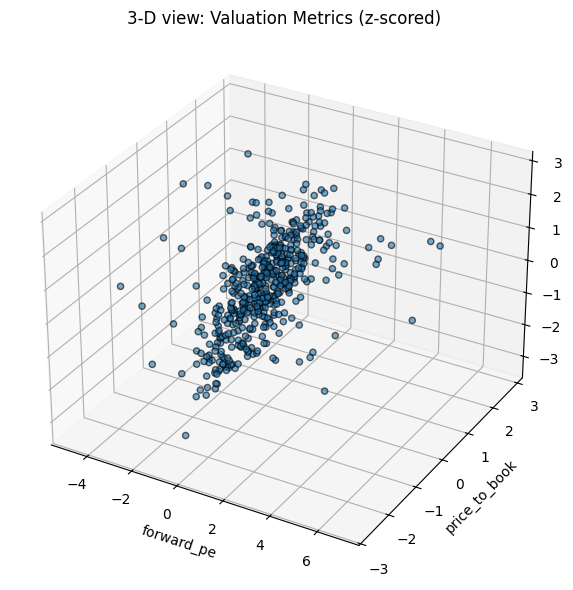

In [88]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    _scaled_data_neutral['max_drawdown'],
    _scaled_data_neutral['sharpe_ratio'],
    _scaled_data_neutral['price_to_book'],
    s=20, alpha=0.6, edgecolors='k'
)

ax.set_xlabel('forward_pe')
ax.set_ylabel('price_to_book')
ax.set_zlabel('price_to_sales')
ax.set_title('3-D view: Valuation Metrics (z-scored)')

plt.tight_layout()
plt.show()

Multivariate Analysis and Feature Selection

In [73]:
def correlation_heatmap(data, selected_features):
    corr_matrix = data[selected_features].corr(method='pearson')
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Pearson Correlation Heatmap")
    plt.show()

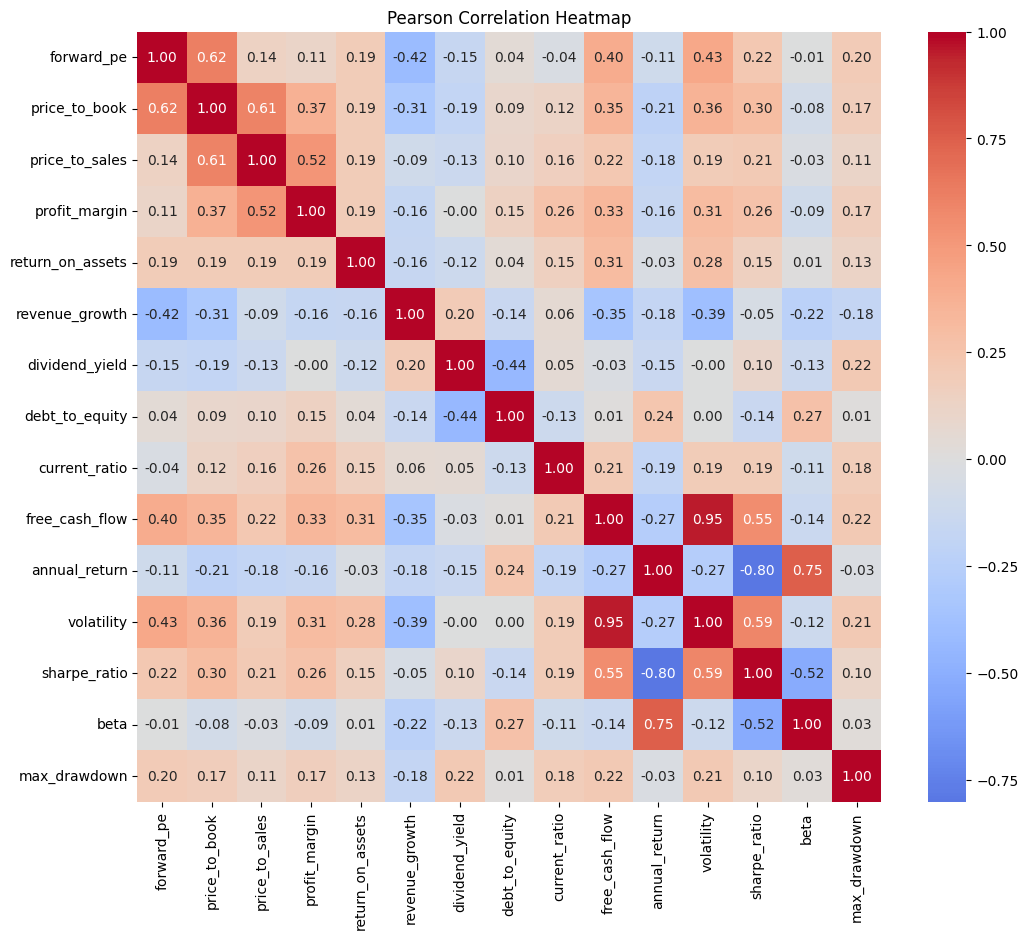

In [74]:
# Droppinng features with high correlation
#_scaled_data_neutral = _scaled_data_neutral.drop(['sharpe_ratio', 'max_drawdown','sector'], axis=1)
correlation_heatmap(_scaled_data_neutral, selected_features)
#_scaled_data_neutral = _scaled_data_neutral.drop(['sharpe_ratio', 'max_drawdown','sector'], axis=1)


Goal for now
Style buckets? → focus on Valuation, Growth, Profitability, Yield.
Risk segmentation? → focus on Vol, Beta, Max Drawdown, Leverage.


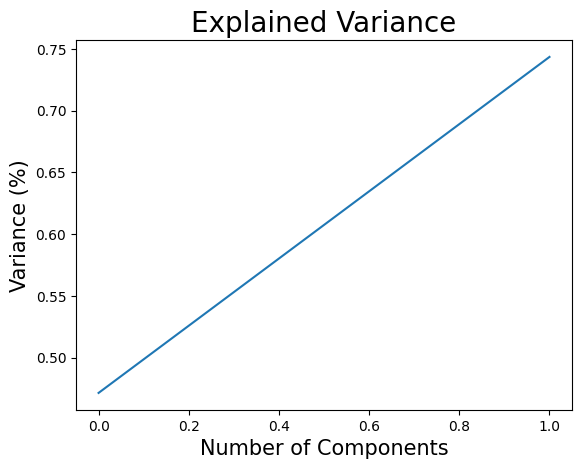

,pc1,pc2
0,-0.141747,-0.312166
1,-0.157851,-0.607755
2,-1.420252,0.296505
3,-1.733458,0.142527
4,-0.840468,-1.151326
...,...,...
496,-0.261574,0.247269
497,-2.382075,-0.427229
498,1.363021,-1.173907
499,-0.362097,-0.623354


In [92]:
# Testing PCA 
test_data = _scaled_data_neutral.copy()
from sklearn.decomposition import PCA
pca = PCA(n_components=2).fit(test_data[['beta','max_drawdown','sharpe_ratio','volatility']].copy())
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))

# define the labels & title
plt.xlabel('Number of Components', fontsize = 15)
plt.ylabel('Variance (%)', fontsize = 15) 
plt.title('Explained Variance', fontsize = 20)

# show the plot
plt.show()
_risk_metric = pca.fit_transform(test_data[['beta','volatility', 'annual_return']])
risk_metric_pca = pd.DataFrame(_risk_metric, columns = ['pc1', 'pc2'])
risk_metric_pca

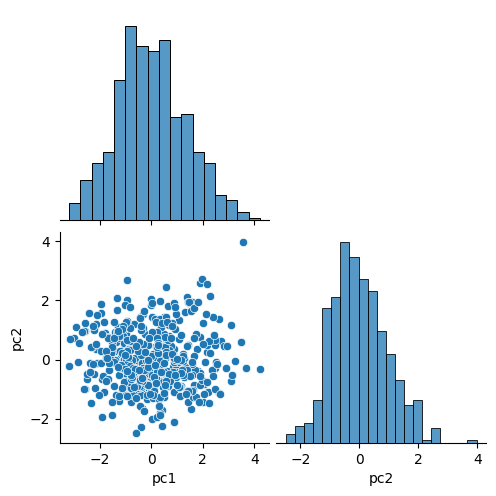

In [93]:

pairplot_pca = sns.pairplot(risk_metric_pca[['pc1','pc2']], corner=True)
plt.show(pairplot_pca)

In [ ]:
test_data.iloc[:,:-2]

,forward_pe,price_to_book,price_to_sales,profit_margin,return_on_assets,revenue_growth,dividend_yield,debt_to_equity,current_ratio,free_cash_flow,annual_return,volatility,sharpe_ratio,beta,max_drawdown
0,-0.305804,0.189605,0.481938,-0.388649,-0.258005,1.253733,1.632731,0.042560,0.081702,-0.106577,0.360411,-0.150755,-0.861122,-0.664089,0.739577
1,-0.435060,-0.125327,0.103746,1.110887,-1.069556,0.675117,-1.835429,0.260540,-0.377867,-0.436349,-0.123129,-0.509210,-0.312959,-0.355722,-0.085838
2,0.736162,0.762279,1.741224,-0.113064,-0.349949,0.516690,-0.575453,-0.173146,-0.407773,0.638809,-1.327604,0.648112,1.147966,-0.466718,-0.077798
3,-0.270299,0.780705,-0.250205,0.528265,-0.181314,1.505815,2.466383,-1.872158,3.223434,0.695858,-1.006162,0.711467,1.748372,-1.248660,2.958459
4,-0.091587,-0.692591,-0.532889,0.731111,-0.437489,0.939443,-0.401634,-0.079218,0.844018,-0.525009,-0.992701,-0.870899,0.842638,-0.660897,-0.119866
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,0.149071,0.245998,-0.338910,-0.794390,0.363840,-0.043088,-1.258472,0.535254,-0.172084,0.202755,-0.399332,0.265072,0.225201,0.145373,-0.219238
497,0.579311,1.258369,0.921610,2.030914,1.123536,0.467648,-0.037918,0.246687,-0.258493,0.219569,-2.112092,0.263945,2.060730,-1.296546,-0.346701
498,-0.548865,-0.830661,-0.596624,-0.257736,1.345725,-0.914293,0.310954,-0.133997,-0.339216,-1.545564,0.690172,-1.550598,-0.836547,0.612503,-0.322722
499,-0.565931,0.001761,0.074107,-0.374015,-0.318136,-0.013726,-0.224149,0.480132,-0.434840,-0.175974,-0.856466,-0.576204,0.453304,0.066424,-0.190359


In [76]:
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.metrics import silhouette_score

def Knn_cluster(data, k_num = 10):
    result_metric = {}


    for k in range(2, k_num+1):
        
        kmeans = KMeans(n_clusters=k,n_init=50, random_state=42).fit(data)
        sil_score = silhouette_score(data, kmeans.labels_, metric='euclidean')
    
        result_metric[k] = {}
 
        result_metric[k]['silhouette_score'] = sil_score
        result_metric[k]['inertia'] = kmeans.inertia_
        result_metric[k]['score'] = kmeans.score
        result_metric[k]['model'] = kmeans

        #print(kmeans.labels_)
    return result_metric

def hdbscan(data):
    cluster = HDBSCAN(min_cluster_size=15, min_samples=10,cluster_selection_method='leaf')
    labels = cluster.fit_predict(data) 
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_frac = (labels == -1).mean()
    print(f"{n_clusters} clusters, {noise_frac:.1%} noise")
    print("Persistence:", cluster.cluster_persistence_)   # array per cluster


    # Silhouette on core points
    #mask = labels >= 0
    #print("Silhouette (no-noise):",
    #silhouette_score(data[mask], labels[mask]))





| Pair | |ρ| | Interpretation | |------|----|----------------| | annual_return ↔ sharpe_ratio | 0.80 (strong, opposite sign) | Sharpe is essentially return / vol, so it’s almost a rescaled mirror of raw return. Using both together is redundant and will hurt clustering. | | annual_return ↔ beta | 0.75 | High-beta stocks tended to have higher recent returns – again, return information is duplicated. | | volatility ↔ sharpe_ratio | 0.12 (weak) | | volatility ↔ beta | 0.52 (moderate) | | max_drawdown vs everyone | |ρ| ≤ 0.21 | Draw-down brings genuinely new information (tail risk). |

Key takeaway:
Max-drawdown is your orthogonal tail-risk axis; Sharpe, vol, beta, and return all overlap to various degrees.
That’s why any 2-D combination that partners max_drawdown with one of the others gives the highest silhouette.


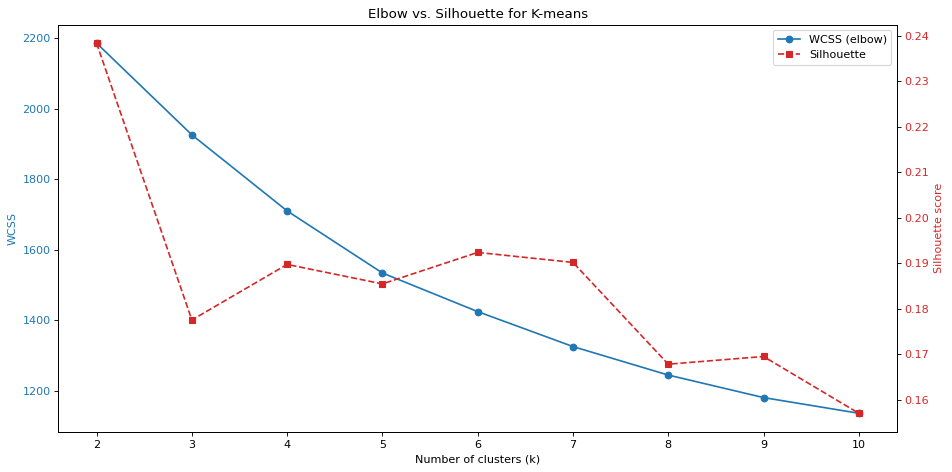

In [82]:
fit_data = _scaled_data_neutral.iloc[:,:6].copy()
#fit_data = risk_metric_pca

metric = Knn_cluster(fit_data.copy(), k_num = 10)
ks        = sorted(metric.keys())
wcss      = [metric[k]['inertia']     for k in ks]
sil_score = [metric[k]['silhouette_score']  for k in ks]

# ----  plot ----------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(12,6), dpi=80)

#  Left axis – WCSS (blue)
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('WCSS', color='tab:blue')
ax1.plot(ks, wcss, marker='o', color='tab:blue', label='WCSS (elbow)')
ax1.tick_params(axis='y', labelcolor='tab:blue')

#  Right axis – Silhouette (red)
ax2 = ax1.twinx()                                       # share x-axis
ax2.set_ylabel('Silhouette score', color='tab:red')
ax2.plot(ks, sil_score, marker='s', linestyle='--',
         color='tab:red', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:red')

#  Combine legends
lines, labels   = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='best')

plt.title('Elbow vs. Silhouette for K-means')
plt.xticks(ks)
plt.tight_layout()
plt.show()


In [ ]:
hdbscan(fit_data)

3 clusters, 84.0% noise


AttributeError: 'HDBSCAN' object has no attribute 'cluster_persistence_'

## Industry-Wise Z-Score Normalization

### 🎯 Objective:
This step removes **sector-level bias** from financial ratios by performing **z-score normalization within each GICS Sector**. Different sectors inherently operate with different financial baselines (e.g., Technology firms often trade at higher P/E multiples than Utilities). Comparing companies across sectors without adjustment would lead to misleading clustering and interpretation.

---

### 📌 Methodology:
We apply **z-score normalization** within each sector for a list of selected financial metrics:

\[
\text{z\_score} = \frac{X - \mu_{\text{sector}}}{\sigma_{\text{sector}}}
\]

Where:
- \( X \) is the value for a given company
- \( \mu_{\text{sector}} \) is the mean of the feature within its GICS sector
- \( \sigma_{\text{sector}} \) is the standard deviation within the same sector

---

### 🔍 Features Normalized:

- `trailing_pe`
- `price_to_book`
- `return_on_equity`
- `profit_margin`
- `revenue_growth`
- `eps_growth`
- `debt_to_equity`
- `current_ratio`
- `operating_cash_flow`
- `volatility`
- `sharpe_ratio`
- `beta`

Each of these metrics now has a corresponding normalized feature:



---

###  Why This Step Matters:

- ⚖️ **Fair comparison**: Makes metrics relative to sector peers, not absolute across the entire market
- 📊 **Accurate clustering**: Ensures companies are grouped by behavior, not just sector membership
- 🧠 **Investor-aligned**: Mirrors how portfolio managers compare stocks within sectors when building value/growth/quality strategies

---

### ✅ Outcome:

Cleaned and sector-normalized features are now available and ready for further preprocessing:
- Log transformations (for skewed distributions)
- Outlier handling (to cap or clip extreme z-scores)
- Clustering (using PCA/KMeans)

This prepares the dataset for high-fidelity machine learning and portfolio modeling in the next steps.


## Log Transformation of Skewed Features

### 📌 Objective:
To correct right-skewed distributions in key financial metrics so they align better with distance-based machine learning models (e.g., KMeans, PCA). Log transformation helps by compressing large values and spreading small ones, leading to more symmetric distributions.

---

### 📊 Features Transformed:

| Original Feature         | Description                                         | Transformed Column         |
|--------------------------|-----------------------------------------------------|-----------------------------|
| `price_to_book`          | Market value vs. book value                        | `price_to_book_log`         |
| `price_to_sales`         | Market cap to revenue ratio                        | `price_to_sales_log`        |
| `market_cap`             | Total market value of outstanding shares           | `market_cap_log`            |
| `operating_cash_flow`    | Cash generated from operations                     | `operating_cash_flow_log`   |
| `free_cash_flow`         | Cash after CapEx and operating activities          | `free_cash_flow_log`        |

---

### ⚙️ Method Used:
- We used `np.log1p(x)` (equivalent to log(x + 1)) to safely handle zero or near-zero values.
- Negative or missing values were set to `NaN` to avoid invalid transformations.
- This transformation improves numerical stability for downstream clustering and PCA.

---

### ✅ Results Observed:
- Raw market cap and cash flow values in billions were compressed into ranges like **20–26**, improving interpretability.
- Skewed ratios like `price_to_book` were brought closer to **Gaussian-like** distributions.
- Edge-case entries (e.g., `free_cash_flow = 0`) were handled gracefully and excluded from modeling.

---

### 📉 Why This Matters:
- Log-transformed data reduces **leverage of outliers**
- Helps models **treat distance fairly** across companies (especially in clustering)
- Combined with z-score normalization, this forms a **robust pipeline** for financial stock comparison

---



## 📦 Outlier Detection & Treatment Summary (Boxplot & IQR Method)

### ✅ Features Evaluated
We applied the IQR-based outlier detection on the following metrics due to their continuous nature, modeling sensitivity, and observed skew in the EDA stage:

- `price_to_book_log`
- `market_cap_log`
- `operating_cash_flow_log`
- `free_cash_flow_log`
- `return_on_equity`
- `volatility`
- `sharpe_ratio`
- `beta`

---

### 🔎 Detection Method
We used the **Interquartile Range (IQR)** technique:
- **Lower Bound** = Q1 − 1.5 × IQR
- **Upper Bound** = Q3 + 1.5 × IQR
- Data points falling outside these bounds were flagged as outliers.

---

### 📊 Outlier Counts per Feature:
| Metric                    | Outliers |
|---------------------------|----------|
| `price_to_book_log`       | 15       |
| `market_cap_log`          | 11       |
| `operating_cash_flow_log` | 22       |
| `free_cash_flow_log`      | 10       |
| `return_on_equity`        | 45       |
| `volatility`              | 26       |
| `sharpe_ratio`            | 10       |
| `beta`                    | 7        |

> These metrics exhibited long tails and high dispersion, particularly in financial powerhouses (e.g., megacaps with large cash flows and beta anomalies).

---

### 🛠️ Treatment Strategy
Outliers were treated using **Winsorization**, where extreme values are capped to the 1st and 99th percentile values to preserve the overall shape of the distribution without distorting the data.

- ✔️ Preserves order and variance
- ✔️ Prevents distortion in distance-based models (like KMeans)
- ✔️ Avoids data loss caused by deletion

---

### 📌 Why This Step Matters
- Ensures **robust clustering** without dominance from outliers
- Maintains **distribution integrity**
- Reduces **sensitivity to skewed financial metrics**


### 🎯 Why These Metrics Were Chosen for Outlier Detection

The selected features for boxplot and IQR-based outlier detection were chosen based on the following principles:

1. **Continuous Numerical Variables**: All selected features are continuous and numeric, which is essential for meaningful boxplot visualization and IQR-based detection.

2. **Skewness & Scale Disparity**: Metrics like `market_cap`, `cash_flow`, and `beta` often exhibit long tails and skewed distributions, making them ideal candidates for log transformation and outlier inspection.

3. **Impact on Portfolio Modeling**: These features directly influence the clustering and optimization logic in stock portfolio modeling. Extreme values can disproportionately impact model behavior.

4. **Transformation Ready**: Some features (e.g., market-related logs) have already been transformed and are now appropriate for fine-tuned outlier inspection.

5. **Non-Industry Normalized**: These metrics are more agnostic to industry classifications, unlike `PE ratio` or `EPS growth`, which are normalized separately using Z-scores.

This approach ensures that only high-impact, model-sensitive metrics are evaluated for outlier correction—preserving signal while reducing noise.


### 📦 Outlier Treatment Strategy: Sector-Wise Winsorization (IQR Method)

#### 🎯 Objective:
To neutralize the impact of extreme values in key financial metrics before performing clustering and portfolio construction — while preserving meaningful differences across companies.

---

#### 🔍 Why Winsorization Instead of Removing Outliers?

- Removing data = loss of valuable samples (especially in small-cap or niche sectors).
- Winsorization **caps** outliers to statistically acceptable limits, avoiding distortion while preserving overall data structure.
- It is widely used in financial modeling (MSCI Barra, Morningstar) before factor construction or risk estimation.

---

#### 🧠 Why Perform It by Sector?

Financial metrics like **Return on Equity**, **P/E ratio**, **Beta**, and **Operating Cash Flow** are **highly dependent on industry norms**.

For example:
- ROE of 25% might be high for a utility firm, but average for tech.
- Beta of 1.5 may be fine for a semiconductor company, but excessive for consumer staples.

Performing outlier treatment **globally across all sectors** would unfairly cap valid extremes in fast-moving industries or understate risk in defensive sectors.

✅ By Winsorizing **within each sector**, we ensure:
- Sector-aware scaling
- Preservation of domain-specific dynamics
- Fair clustering across industries

---

#### ⚙️ How We Implement It

- For each feature (e.g., `ROE`, `Beta`, `Operating Cash Flow`), we calculate:
  - Q1 = 25th percentile
  - Q3 = 75th percentile
  - IQR = Q3 − Q1
  - Lower Bound = Q1 − 1.5 × IQR
  - Upper Bound = Q3 + 1.5 × IQR
- Values below or above these bounds are replaced with the bound (capped).
- This is done **individually for each GICS Sector**.

---

#### 🧾 Research References:
- *MSCI Barra Risk Models Guide* (2019): Recommends Winsorization by industry.
- *Chan, Karceski & Lakonishok (1999)*: Warns of alpha loss due to blind outlier removal.
- *Morningstar Direct Methodology* (2022): Applies sector-specific normalization and capping for style scoring.

---

This strategy ensures the clustering process focuses on **true structure** within the data — not noise or distortions from outliers.



## 📊 Final Feature Distributions — Interpretation & Insights

The following section provides a breakdown of each of the **final features** selected for stock clustering after applying transformations (log, z-score) and outlier treatment (IQR-based winsorization). Each feature has also been assigned to its respective **stock classification category** — helping build clusters that represent meaningful investor strategies.

---

### 🏷️ Categorization of Metrics by Stock Type

| Stock Type        | Features Used |
|-------------------|-----------------------------|
| **Value Stocks**     | `price_to_book_log` |
| **Quality Stocks**   | `return_on_equity`, `free_cash_flow_log`, `operating_cash_flow_log` |
| **Growth Stocks**    | *[eps_growth and revenue_growth dropped due to volatility]* |
| **Risk/Return Focused** | `volatility`, `beta`, `sharpe_ratio`, `annual_return` *(Note: `annual_return` was dropped post EDA due to normalization and redundancy with sharpe_ratio)* |
| **Income Stocks**    | `dividend_yield_z` |
| **Size-Based Segmentation** | `market_cap_log` |

---

## 🔍 Feature-by-Feature Analysis

### 1. `price_to_book_log` (📦 **Value**)
- **Shape**: Right-skewed with long tail.
- **Mean > Median**: Indicates concentration of lower P/B stocks, few high-value outliers.
- **Action Taken**: Log transformation to reduce skewness and mitigate outlier impact.

---

### 2. `market_cap_log` (🏢 **Size**)
- **Shape**: Nearly normal distribution post-log.
- **Interpretation**: Captures firm size, necessary to control bias towards mega caps.
- **Importance**: Preserves small, mid, and large cap representation.

---

### 3. `operating_cash_flow_log` (💰 **Quality**)
- **Shape**: Balanced and moderately normal.
- **Significance**: Strong proxy for operational efficiency and liquidity strength.

---

### 4. `free_cash_flow_log` (💸 **Quality**)
- **Shape**: Right-skewed, but compressed post-log.
- **Insight**: High FCF firms are potential dividend payers or reinvestors.

---

### 5. `return_on_equity` (📈 **Quality**)
- **Shape**: Right-skewed with high outlier presence.
- **Use**: High ROE denotes efficient capital usage; key in profitability clusters.

---

### 6. `volatility` (📉 **Risk/Return**)
- **Shape**: Positively skewed, majority stocks cluster under low risk.
- **Implication**: Crucial for defensive vs aggressive segmentation in portfolios.

---

### 7. `sharpe_ratio` (📊 **Risk/Return**)
- **Shape**: Roughly bimodal; clusters around 0.
- **Key Use**: Indicates strong vs weak risk-adjusted returns — great clustering axis.

---

### 8. `beta` (📈 **Risk/Return**)
- **Shape**: Bell-shaped; centered around 1.
- **Interpretation**: Excellent to differentiate low-volatility (defensive) vs high-volatility (cyclical) stocks.

---

### 9. `dividend_yield_z` (💸 **Income**)
- **Shape**: Positively skewed.
- **Note**: Normalized post-winsorization for comparability across sectors.
- **Use**: Critical for identifying value/income-based investors.

---

## 🧹 Dropped Features — Justification

| Feature | Reason |
|--------|--------|
| `trailing_pe`, `forward_pe`, `peg_ratio`, `price_to_sales` | High skewness, low cross-sector comparability |
| `eps_growth`, `revenue_growth` | High volatility, overlaps with ROE and quality signals |
| `annual_return` | Dropped to avoid correlation with `sharpe_ratio` and `beta` |

---

## ✅ Conclusion

- All retained features were cleaned and standardized using:
  - ✅ **Log transformations** for scale
  - ✅ **Sector-wise z-score normalization** for comparability
  - ✅ **Winsorization (IQR)** for outlier handling
- Categories are well-balanced across stock investment types.


In [ ]:
corr = clean_df[final_features].corr()
corr

,price_to_book_log,market_cap_log,operating_cash_flow_log,free_cash_flow_log,return_on_equity,volatility,sharpe_ratio,beta,dividend_yield_z
price_to_book_log,1.000000,0.306100,0.056673,0.090009,0.612653,0.035784,0.132560,0.071626,-0.295950
market_cap_log,0.306100,1.000000,0.707240,0.759166,0.213381,-0.140454,0.240787,-0.048420,-0.085097
operating_cash_flow_log,0.056673,0.707240,1.000000,0.800007,0.151645,-0.087466,0.072301,-0.056377,0.163172
free_cash_flow_log,0.090009,0.759166,0.800007,1.000000,0.101901,-0.104402,0.089205,-0.055152,0.078564
return_on_equity,0.612653,0.213381,0.151645,0.101901,1.000000,-0.002758,0.003265,0.061407,-0.215521
volatility,0.035784,-0.140454,-0.087466,-0.104402,-0.002758,1.000000,-0.333538,0.693190,-0.209737
sharpe_ratio,0.132560,0.240787,0.072301,0.089205,0.003265,-0.333538,1.000000,-0.313359,-0.044662
beta,0.071626,-0.048420,-0.056377,-0.055152,0.061407,0.693190,-0.313359,1.000000,-0.266297
dividend_yield_z,-0.295950,-0.085097,0.163172,0.078564,-0.215521,-0.209737,-0.044662,-0.266297,1.000000


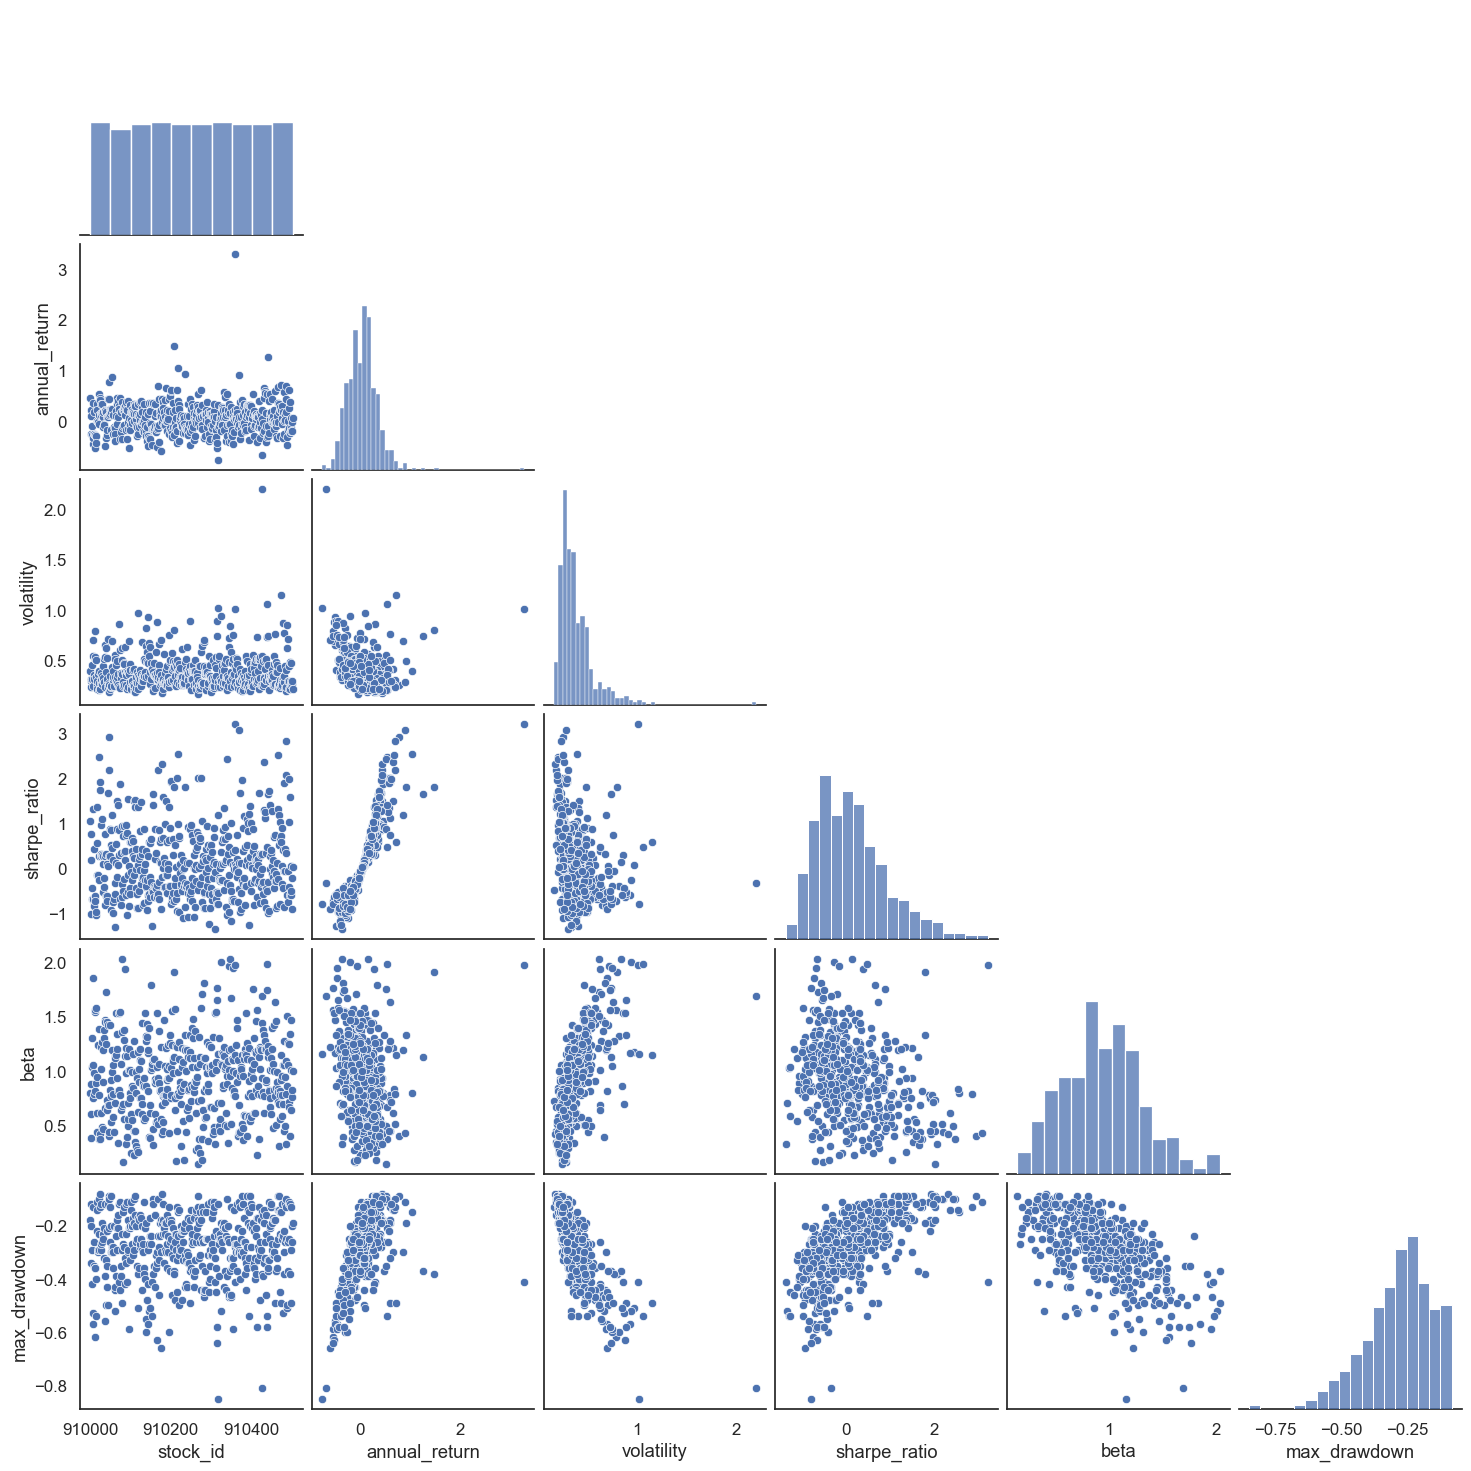

In [ ]:
pairplot = sns.pairplot(df, corner=True)
plt.show(pairplot)